# **===========================================================================================================================================================** #
# **Unit 5 End Project - Natural Language Processing** #
# **===========================================================================================================================================================** #
**Streamlining the Customer Grievance Process**: Create a model that processes customer reviews.</br>
This is a **Sentiment Analyzer** problem where we are trying analyze and categorize customer reviews..</br>

## Setup

### Imports

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'    # must be first

import time
import subprocess
import tensorflow as tf                     
#import tf_keras
#import transformers

from transformers.utils import is_tf_available
print(f'TF available to transformers: {is_tf_available()}')
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification

import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
from collections import Counter


#from tensorflow.keras.preprocessing.text import Tokenizer
#from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
#from tensorflow.keras.metrics import Precision, Recall, AUC

from sklearn.metrics import (
    accuracy_score,                         
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, ConfusionMatrixDisplay,
    classification_report, precision_score,
    recall_score, f1_score, roc_auc_score,
    balanced_accuracy_score
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import label_binarize
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# Initialize the vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from wordcloud import WordCloud
from bs4 import BeautifulSoup
from spellchecker import SpellChecker
import json

result = subprocess.run(['pip', 'show', 'tf-keras'], capture_output=True, text=True)
print(result.stdout)


/home/vscode/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TF available to transformers: True
Name: tf_keras
Version: 2.20.1
Summary: Deep learning for humans.
Home-page: https://keras.io/
Author: Keras team
Author-email: keras-users@googlegroups.com
License: Apache 2.0
Location: /home/vscode/.local/lib/python3.10/site-packages
Requires: tensorflow
Required-by: 



#### Track Notebook Runtime Performance ####

In [2]:
# For Tracking Notebook runtime/performance
notebook_start_time = time.time()

### Configuration

In [3]:
# GloVe download settings
# Keep this, we might use GloVe if time permits
# glove_dir = '../data'
# glove_url = 'https://nlp.stanford.edu/data/glove.twitter.27B.zip'

# Download NLTK resources
nltk.download('stopwords', quiet=True)

# Set up stop words and tokenizer
stop_words = set(stopwords.words('english'))

# Force CPU only
tf.config.set_visible_devices([], 'GPU')

2026-03-23 06:17:02.802151: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Utility Functions
These utility/support methods will eventually be pushed into a private support library (Yes, I know, I know....).

#### EDA Utility Functions ####

In [4]:
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(dataset_name, df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    sample_size = min(20, len(df_target))

    print("***********************************")
    print("First N rows of Data")
    print("***********************************")
    print()
    print(df_target.head(sample_size))
    print()

    print("***********************************")
    print("First N rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=sample_size)
    print(df_target.sample(sample_size))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{dataset_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{dataset_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{dataset_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{dataset_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{dataset_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{dataset_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{dataset_name} Random Data Sample')
        
    print()

#### Plotting Utility Functions ####

In [5]:
def DisplayBarPlot(df_Target, x_axis, y_axis, 
                    x_axis_label=None,
                    y_axis_label='Count',
                    plot_title=None, 
                    colors=None,
                    fmt='%.0f'):

    # Plot
    plt.figure(figsize=(12, 6))

    if colors:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette=colors,
                        legend=False)
    else:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette='Blues_d', 
                        legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis_label, fontweight='bold')
    plt.ylabel(y_axis_label, fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt=fmt)

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, hue_value=None, plot_labels=None, displayLabels=True):

    if hue_value is not None:
        hue = hue_value
    else:
        hue = x_axis

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=hue, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    if plot_labels is not None:
        plt.legend(title=hue, labels=plot_labels)

    plt.tight_layout()
    plt.show()

def DisplayGroupedCountPlot(df_target, x_axis, hue_col, plot_title, fig_size, top_n=None):
    
    # Optionally limit to top N categories on x_axis
    if top_n is not None:
        top_cats = df_target[x_axis].value_counts().head(top_n).index
        df_target = df_target[df_target[x_axis].isin(top_cats)]

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis,
                       data=df_target,
                       hue=hue_col,
                       palette='Blues_d',
                       order=df_target[x_axis].value_counts().index)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()   

def PlotLearningCurves(history, plot_title):

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].set_title(f'{plot_title}: loss')
    axes[0].plot(history['loss'], label='Training')
    axes[0].plot(history['val_loss'], label='Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (binary crossentropy)')
    axes[0].legend(loc='best')

    axes[1].set_title(f'{plot_title}: accuracy')
    axes[1].plot(history['accuracy'], label='Training')
    axes[1].plot(history['val_accuracy'], label='Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

def PlotConfusionMatrix(model, X_test, y_test, plot_title):

    y_probs = model.predict(X_test).flatten()
    y_pred = (y_probs >= 0.5).astype(int)

    print('----------------------------------------------------------')
    print(plot_title)
    print()
    print(classification_report(y_test, y_pred, target_names=['Not Recommend', 'Recommend']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_probs):.4f}')
    print('----------------------------------------------------------')

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Recommend', 'Recommend'])
    disp.plot(cmap='Blues')
    plt.title(plot_title)
    plt.show() 


#### Model Comparison Utility Functions ####

In [6]:
def GetPredictions(name, results):
    model  = results['model']
    X_test = results['X_test']

    if name == 'DistilBERT':
        logits = model.predict(
                     {'input_ids':      X_test['input_ids'],
                      'attention_mask': X_test['attention_mask']}
                 ).logits
        probs  = tf.nn.softmax(logits, axis=-1).numpy()
        return np.argmax(probs, axis=-1)
    else:
        return model.predict(X_test)


def PlotConfusionMatrices(results_dict):
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

    if n_models == 1:
        axes = [axes]

    palettes = ['Blues', 'Greens', 'Oranges', 'Purples']

    for i, (name, results) in enumerate(results_dict.items()):
        y_test           = results['y_test']
        test_predictions = GetPredictions(name, results)
        cm               = confusion_matrix(y_test, test_predictions)

        sns.heatmap(cm, annot=True, fmt='d', cmap=palettes[i % len(palettes)],
                    ax=axes[i], cbar=True)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    plt.suptitle('Confusion Matrix Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print()


def CompareClassificationResults(results_dict, title='Classifier Comparison'):

    sns.set_style("whitegrid")

    #
    # 1. Calculate all metrics
    #
    metrics_data = []
    for name, results in results_dict.items():
        y_test           = results['y_test']
        test_predictions = GetPredictions(name, results)
        report           = results['report']

        metrics_data.append({
            'Model':             name,
            'Train Accuracy':    results['train_accuracy'],
            'Test Accuracy':     results['test_accuracy'],
            'Balanced Accuracy': balanced_accuracy_score(y_test, test_predictions),
            'Precision':         precision_score(y_test, test_predictions, average='weighted'),
            'Recall':            recall_score(y_test,    test_predictions, average='weighted'),
            'F1 Score':          results['f1_score'],
            'Gap':               results['train_accuracy'] - results['test_accuracy']
        })

    df_comparisons = pd.DataFrame(metrics_data).set_index('Model')

    #
    # 2. Print Metrics Table
    #
    print('=' * 70)
    print(title)
    print('=' * 70)
    print(df_comparisons.round(4))
    print()

    DisplayTable(df_comparisons, 'Classification Comparisons', show_index=True)

    #
    # 3. Accuracy Comparison (Train vs Test vs Balanced)
    #
    accuracy_metrics = []
    for name, results in results_dict.items():
        y_test           = results['y_test']
        test_predictions = GetPredictions(name, results)

        accuracy_metrics.append({'Model': name, 'Metric': 'Train Accuracy',    'Score': results['train_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Test Accuracy',     'Score': results['test_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Balanced Accuracy', 'Score': balanced_accuracy_score(y_test, test_predictions)})

    acc_df = pd.DataFrame(accuracy_metrics)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=acc_df, x='Metric', y='Score', hue='Model', palette='deep')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Accuracy Metrics Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()

    #
    # 4. Precision / Recall / F1 Comparison
    #
    prf_metrics = []
    for name, results in results_dict.items():
        y_test           = results['y_test']
        test_predictions = GetPredictions(name, results)

        prf_metrics.append({'Model': name, 'Metric': 'Precision', 'Score': precision_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'Recall',    'Score': recall_score(y_test,    test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'F1 Score',  'Score': results['f1_score']})

    prf_df = pd.DataFrame(prf_metrics)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=prf_df, x='Metric', y='Score', hue='Model', palette='Set2')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Precision / Recall / F1 Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()

    #
    # 5. Gap Comparison (Overfitting indicator)
    #
    gap_data = pd.DataFrame({
        'Model': list(results_dict.keys()),
        'Gap':   [r['train_accuracy'] - r['test_accuracy'] for r in results_dict.values()]
    })

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')
    ax.bar_label(ax.containers[0], fmt='%.4f', fontsize=10)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title('Overfitting Indicator (Lower is Better)', fontweight='bold')
    plt.ylabel('Train - Test Accuracy Gap')
    plt.tight_layout()
    plt.show()
    print()

    #
    # 6. Confusion Matrices
    #
    PlotConfusionMatrices(results_dict)

    #
    # 7. Metrics Heatmap
    #
    plt.figure(figsize=(12, len(results_dict) * 0.8 + 2))
    heatmap_cols = ['Test Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score']
    sns.heatmap(df_comparisons[heatmap_cols], annot=True, fmt='.4f', cmap='YlGnBu',
                vmin=0, vmax=1, linewidths=0.5)
    plt.title('Model Metrics Heatmap', fontweight='bold')
    plt.tight_layout()
    plt.show()

    #
    # 8. Plot Classification Report Results
    #
    for i, (name, results) in enumerate(results_dict.items()):
        report    = results['report']
        df_result = pd.DataFrame(report)
        DisplayTable(df_result,
                     f'{name} Classification Report',
                     show_index=True)

    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))

    if n_models == 1:
        axes = [axes]

    for i, (name, results) in enumerate(results_dict.items()):
        report    = results['report']
        df_report = pd.DataFrame(report).T
        df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
        df_report = df_report.drop(columns=['support'], errors='ignore')

        sns.heatmap(df_report, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=0, vmax=1, ax=axes[i], linewidths=0.5)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_ylabel('Class')
        axes[i].set_xlabel('Metric')

    plt.suptitle('Classification Reports Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    #
    # 9. ROC Curves
    #
    plt.figure(figsize=(10, 6))
    for name, results in results_dict.items():
        if 'y_test_prob' not in results:
            continue
        y_test      = results['y_test']
        y_test_prob = results['y_test_prob']
        classes     = sorted(np.unique(y_test))
        roc_auc     = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')
        fpr, tpr, _ = roc_curve(label_binarize(y_test, classes=classes).ravel(),
                                y_test_prob.ravel())
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate',  fontweight='bold')
    plt.title('ROC Curves Comparison', fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print()

    #
    # 10. Precision-Recall Curves
    #
    plt.figure(figsize=(10, 6))
    for name, results in results_dict.items():
        if 'y_test_prob' not in results:
            continue
        y_test      = results['y_test']
        y_test_prob = results['y_test_prob']
        classes     = sorted(np.unique(y_test))
        precision, recall, _ = precision_recall_curve(
            label_binarize(y_test, classes=classes).ravel(),
            y_test_prob.ravel()
        )
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})')

    plt.xlabel('Recall',    fontweight='bold')
    plt.ylabel('Precision', fontweight='bold')
    plt.title('Precision-Recall Curves Comparison', fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print()

    return df_comparisons

## 1.0 Load Data ## 

In [7]:
df_complaints = pd.read_csv('../../data/Unit5EndProject/complaints_banking_2023.csv')
df_departments = pd.read_csv('../../data/Unit5EndProject/Department_of_Product.csv')
df_issues = pd.read_csv('../../data/Unit5EndProject/Issues.csv')

# Make copies of the original unmodified data
df_complaints_Original = df_complaints.copy(deep=True)
df_departments_Original = df_departments.copy(deep=True)
df_issues_Original = df_issues.copy(deep=True)

## 2.0 Examining Sample Data from the Labeled Review Dataset ##
#### **Text Preprocessing**  ####

For starters, let's tokenize and have a look at a sample (first 500 characters of "Target Features" [0] for each dataset)</br>
The Target Feature that we really want to focus on is "
This is just a way to get a feel for how these methods work, what they do and what the data generally looks like.</br>
</br>
Initial examination showed that there were embedded html tokens in the review text; mostly "**</br>**" (line breaks).</br>
We could deal with the embedded html in 1 of 2 methods:
- Regular Expressions
- Using the BeautifulSoup library (which I found thru research) 
</br>
In the spirit of learning new things, I chose "BeautifulSoup"

#### Load and Examine Sample Set ####
Normalization and Cleaning
- Text normalization includes lowercasing, removing punctuation, and filtering stopwords.

In [8]:
def ExamineDataSampleSet(dataset_name, df_target, target_label):

    print()    
    print('=' * 60)
    print(f"Sample Data Examination for: {dataset_name}".center(22, '='))
    print(f"Target Feature: {target_label}".center(22, '='))
    print('=' * 60)
    print()
    print()
    print(df_target.columns)

    # 1. Basic Clean up, tokenization and examination
    # Sample text for initial investigation
    sample_text = df_target[target_label].iloc[0][:500]

    #print(type(sample_text))
    print(f'Original text:\n{sample_text}\n')

    # Remove HTML tags
    sample_text = BeautifulSoup(sample_text, 'html.parser').get_text()
    print(f'Text After HTML tags removed:\n{sample_text}\n')

    # Word tokenization
    word_tokens = word_tokenize(sample_text)
    print(type(word_tokens))

    # Sentence tokenization
    sent_tokens = sent_tokenize(sample_text)

    print(f'Word tokens ({len(word_tokens)} tokens):\n{word_tokens[:20]}...\n')
    print(f'Sentence tokens ({len(sent_tokens)} sentences):\n{sent_tokens[:2]}')

    # 2. Normalization and Cleaning
    # Lowercase
    print('=' * 60)
    print("Normalization and Cleaning".center(22, '='))
    print('=' * 60)
    tokens_lower = [token.lower() for token in word_tokens]

    # Remove non-alphabetic tokens
    tokens_alpha = [token for token in tokens_lower if token.isalpha()]

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens_clean = [token for token in tokens_alpha if token not in stop_words]

    print(f'Original tokens: {len(word_tokens)}')
    print(f'After lowercasing: {len(tokens_lower)}')
    print(f'After removing non-alpha: {len(tokens_alpha)}')
    print(f'After removing stopwords: {len(tokens_clean)}')
    print(f'\nCleaned tokens:\n{tokens_clean[:15]}')


    # 3. Stemming and Lemmatization
    # Lowercase
    print('=' * 60)
    print("Stemming and Lemmatization".center(22, '='))
    print('=' * 60)
    tokens_lower = [token.lower() for token in word_tokens]

    # Stemming
    stemmer = PorterStemmer()
    tokens_stemmed = [stemmer.stem(token) for token in tokens_clean]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens_lemmatized = [lemmatizer.lemmatize(token) for token in tokens_clean]

    # Compare results
    comparison_df = pd.DataFrame({
        'original': tokens_clean[:50],
        'stemmed': tokens_stemmed[:50],
        'lemmatized': tokens_lemmatized[:50]
    })

    comparison_df

    ### 4. Normalization and cleaning of Sample Data
    # Lowercase
    print('=' * 60)
    print("Normalization and Cleaning".center(22, '='))
    print('=' * 60)
    tokens_lower = [token.lower() for token in word_tokens]
    tokens_lower = [token.lower() for token in word_tokens]

    # Remove non-alphabetic tokens
    tokens_alpha = [token for token in tokens_lower if token.isalpha()]

    # Remove stopwords
    stop_words = set(stopwords.words('english'))

    # Initially, I just handled this by adding 'br' to stopwords, but that really
    # doesn't address issue. Needed to preprocess all embedded <HTML> tags from text
    # This is now done in a previous sell using BeautifulSoup()
    # To handle embedded html linebreaks
    #stop_words.add('br')

    tokens_clean = [token for token in tokens_alpha if token not in stop_words]

    print(f'Original tokens: {len(word_tokens)}')
    print(f'After lowercasing: {len(tokens_lower)}')
    print(f'After removing non-alpha: {len(tokens_alpha)}')
    print(f'After removing stopwords: {len(tokens_clean)}')
    print(f'\nCleaned tokens:\n{tokens_clean[:15]}')

    print('=' * 60)
    print('=' * 60)
    print()
    print()
    print()

ExamineDataSampleSet("Complaints", df_complaints, 'Complaint Description')    
ExamineDataSampleSet("Complaints", df_complaints, 'Bank Response')    
ExamineDataSampleSet("Issues", df_issues, 'Issue')    
ExamineDataSampleSet("Departments", df_departments, 'Product')    


Sample Data Examination for: Complaints
Target Feature: Complaint Description


Index(['Complaint ID', 'Date Received', 'Banking Product', 'Department',
       'Issue ID', 'Complaint Description', 'State', 'ZIP', 'Bank Response'],
      dtype='object')
Original text:
on XX/XX/XX22 I opened a safe balance account online using my payroll check of over {$600.00} as my account opener. On XX/XX/XX22, I attempted to login to my app and received a " account locked contact customer service @ XXXX '' error message. I placed the call and was told I would have to go to a branch to verify my identity, which I did. At the same time, I was told I had a positive balance of of {$650.00} and could make a withdrawal from the teller, which I did for {$400.00} leaving a balance

Text After HTML tags removed:
on XX/XX/XX22 I opened a safe balance account online using my payroll check of over {$600.00} as my account opener. On XX/XX/XX22, I attempted to login to my app and received a " account locked conta

## 3.0 Exploratory Data Analysis (EDA)
Examine each of the 3 datasets.
Need to determine if we need to combine any.

In [9]:
#PrintDataFrameStatistics('Complaints', df_complaints)
print()

#PrintDataFrameStatistics('Issues', df_issues)
print()

#PrintDataFrameStatistics('Departments', df_departments)
print()

### 3.1 EDA Analysis and Initial Data Wrangling ###
Looking at the 3 datasets, it makes sense to join them into 1 </br>
Complaints <== Issue ID ==> Issues</br>
Department of Product - Really just a table of Products/Departments</br>
#### Complaints - EDA Analysis ####
- 7000+ rows of data
- Missing Data: 
    - Pretty much every feature has missing values
    - I don't think it make necessarily makes sense to impute the missing values.</br>
    I think if we impute, we will end up forcing values on empty features which might not make sense or</br>
    could skew the analysis/findings.</br>
    A better plan is create a "Others" value which will catch the missing values.</br>
    I'll start with that and then examine the data. If needed I can always come back and impute.</br>
    - The most meaningful missing values (that we care about are):
        - Bank Product
        - Department
    - The remaining features which could be use full for analysis/predictions (New Jersey complains way more than anybody else..)
        - State, Zip - missing features can be replaces with "Others"
- Data Conversion
    - The dataset doesn't deal with any continuous values. </br>
    Really the only feature it makes sense to Convert is **Date Received** from a string to a real date. </br>
    That way we could bin/plot complaints against date ranges and see if there's any trends.</br>

In [10]:
columns = ['Banking Product', 'Department', 'Complaint Description', 'State', 'ZIP', 'Bank Response' ]

# Catch empty columns with whitespace only as well
df_complaints[columns] = (df_complaints[columns]
                       .apply(lambda col: col.str.strip() if col.dtype == 'object' else col)
                       .replace('', 'Other')
                       .fillna('Other'))                       

# Convert Date Received 
df_complaints['Date Received'] = pd.to_datetime(df_complaints['Date Received'], errors='coerce')
#print(df_complaints['Date Received'].dtype)

#PrintDataFrameStatistics('Complaints', df_complaints)
print()

#### Issues - EDA Analysis ####
- Departments -> Department 
    - No missing values
    - No data transformations/conversions required
    - Target categories where complaints will be routed</br>
    Grab the unique values and hold onto them for later use.</br>
    There 130 unique issue names.</br>
    Display the top 50 reported issues </br>

There 130 Unique Issue Names
['Closing an account'
 "Problem with a credit reporting company's investigation into an existing problem"
 'Managing an account' 'Fees or interest' 'Unexpected or other fees'
 'Improper use of your report' 'Attempts to collect debt not owed'
 'Problem with a purchase or transfer'
 'Incorrect information on your report'
 'Problem with a purchase shown on your statement'
 'Problem caused by your funds being low'
 'Problem with a lender or other company charging your account'
 'Trouble using the card' 'Opening an account' 'Closing your account'
 'Fraud or scam' 'Struggling to pay mortgage'
 'Money was not available when promised' 'Getting a credit card'
 'Applying for a mortgage or refinancing an existing mortgage'
 'Trouble during payment process' 'Other features, terms, or problems'
 'Managing the loan or lease'
 'Problem getting a card or closing an account'
 'Confusing or misleading advertising or marketing'
 'Advertising and marketing, including promotion

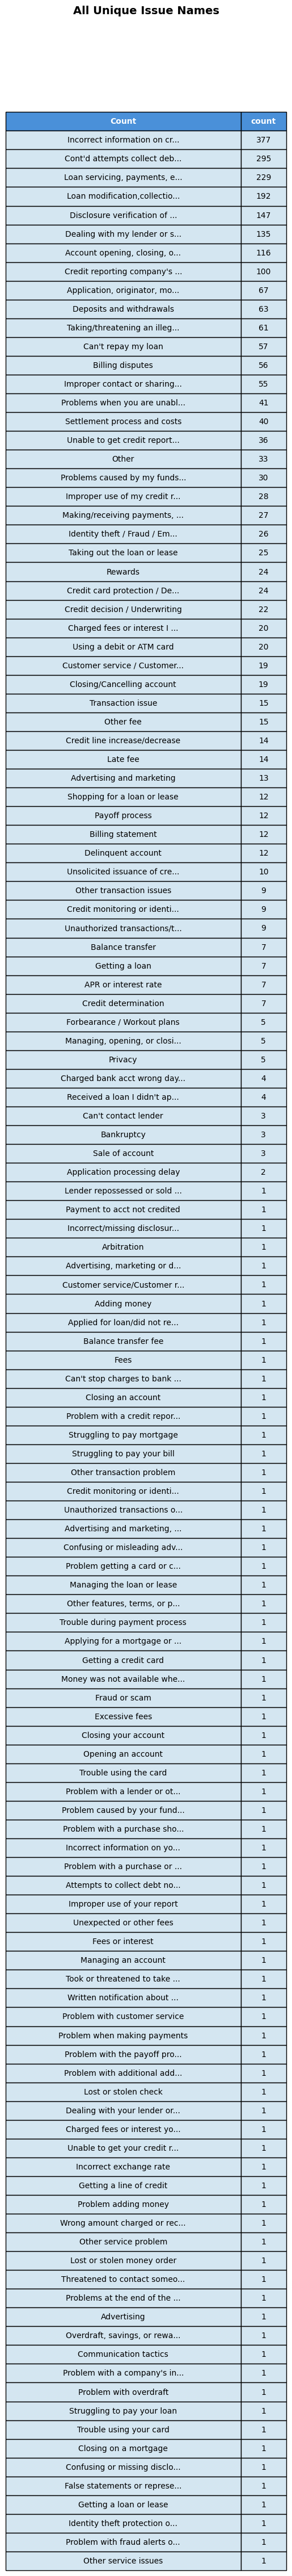

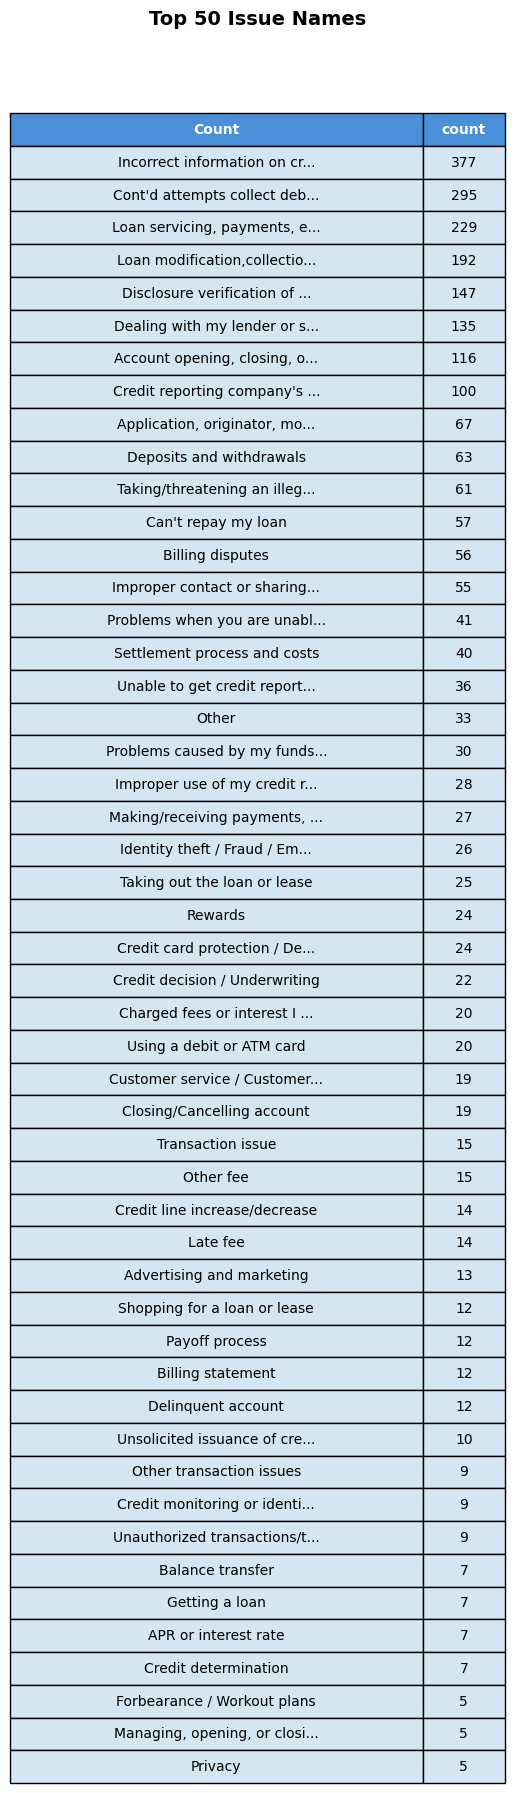

In [11]:
# Issues
issue_names = df_issues['Issue'].unique()

print(f'There {len(issue_names)} Unique Issue Names')
print(issue_names)

df_issue_counts = (df_issues['Issue']
                   .value_counts()
                   .reset_index()
                   .rename(columns={'index': 'Issue', 'Issue': 'Count'}))

df_issue_counts.index += 1  
df_issue_counts.index.name = 'Rank'
DisplayTable(df_issue_counts, 'All Unique Issue Names')
DisplayTable(df_issue_counts.head(50), 'Top 50 Issue Names')

#### Departments - EDA Analysis ####
- Departments -> Department 
    - No missing values
    - No data transformations/conversions required
    - Target categories where complaints will be routed</br>
    Grab the unique values and hold onto them for later use.</br>
    There 7 unique department names.</br>
    There 17 unique product names.</br>

In [12]:
# Departments
department_names = df_departments['Department'].unique()

print(f'There {len(department_names)} Unique Department Names')
print(department_names)

# Products
product_names = df_departments['Product'].unique()
print(f'There {len(product_names)} Product Names')
print(product_names)

There 7 Unique Department Names
['CASA' 'Credit Reports' 'Credit Cards' 'Loans' 'Remittance' 'Mortgage'
 'Others']
There 17 Product Names
['Checking or savings account'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Credit card or prepaid card' 'Debt collection'
 'Money transfer, virtual currency, or money service' 'Mortgage'
 'Vehicle loan or lease' 'Payday loan, title loan, or personal loan'
 'Student loan' 'Credit Card' 'Credit Reporting' 'Payday loan'
 'Bank Account or Service' 'Money transfers' 'Prepaid Card'
 'Consumer Loan' 'Other financial service']


In [13]:
#### Merge Issues into Complaints Data Frame
df_complaints_and_issues = pd.merge(df_complaints, df_issues, left_on='Issue ID', right_on='Issue_ID', how='left')

df_complaints_and_issues.drop(columns=['Complaint ID', 'Issue_ID'], inplace=True)

# PrintDataFrameStatistics('Merged Complaints And Issues', df_complaints_and_issues)
# print()

#### Merge Datasets into 1 DataFrame ####
Merge issues dataset into complaints so issues are included in complaint dataset.</br>
Complaint dataset will contain all relative data. </br>
</br>
Dropping **ComplaintID** and **Issue ID** columns from dataset as they serve no predictive or analytical purpose.</br>
They are unique identifiers "imported" from original system/dataset.

### 3.2 Plotting Data for Additional Insights

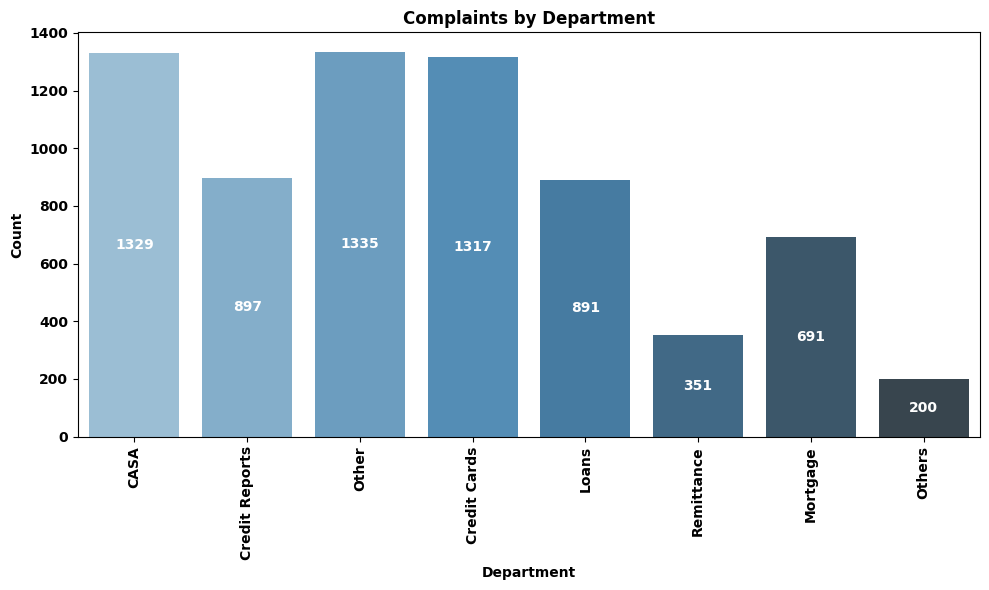

/tmp/ipykernel_40627/3983791333.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


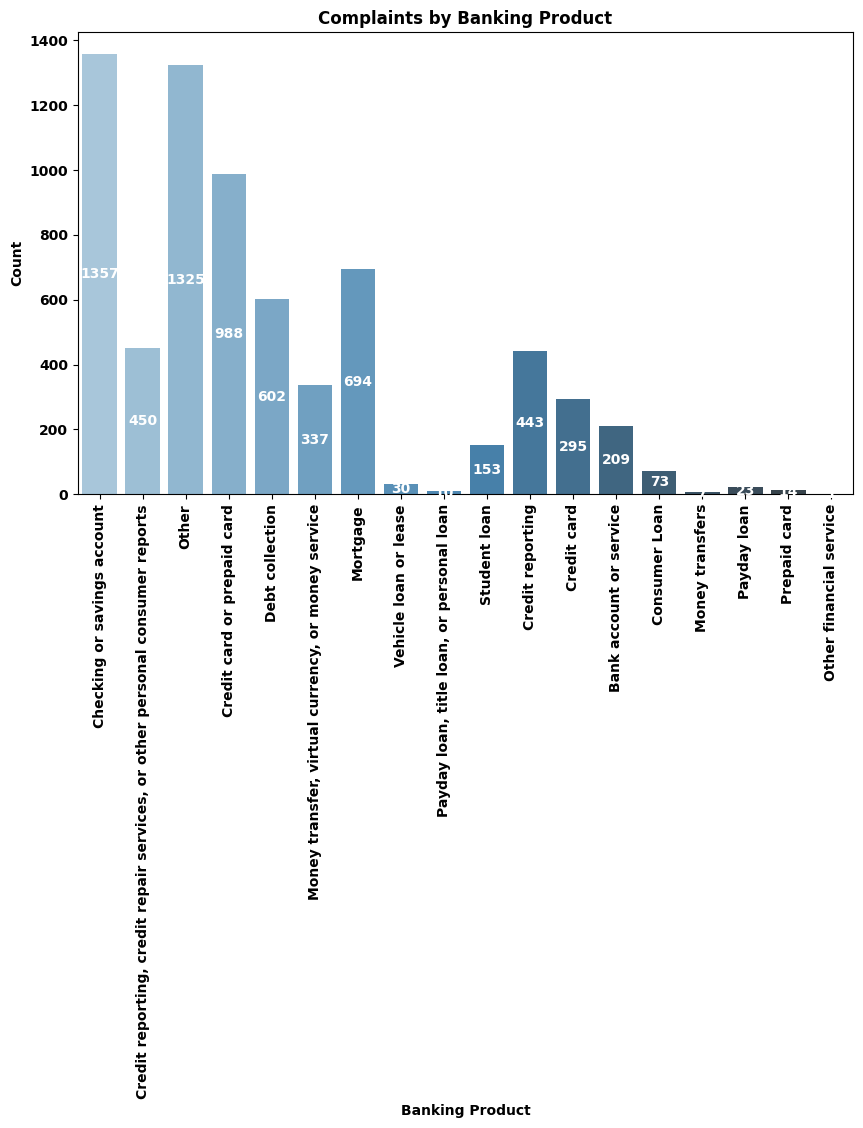

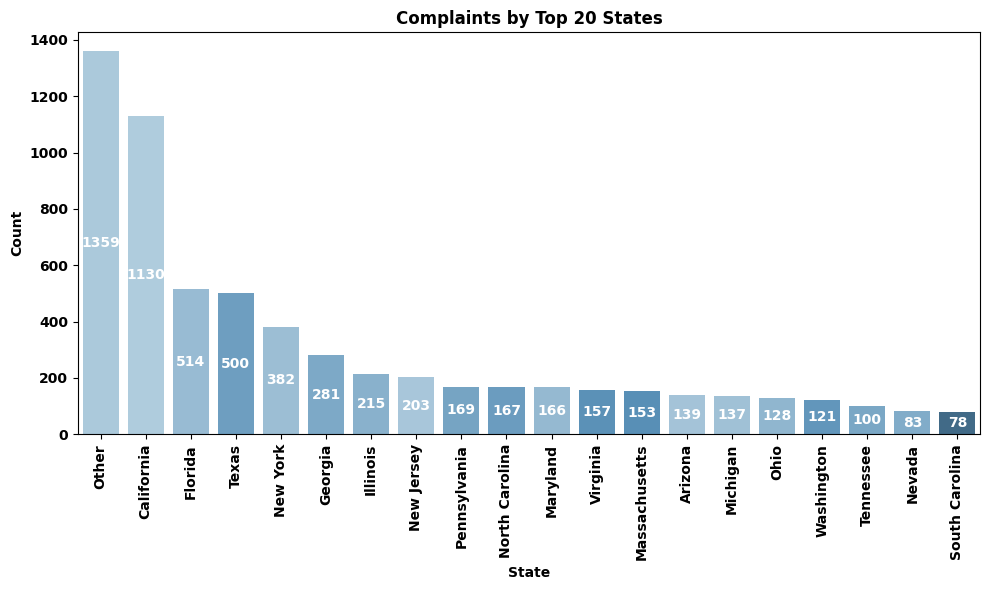

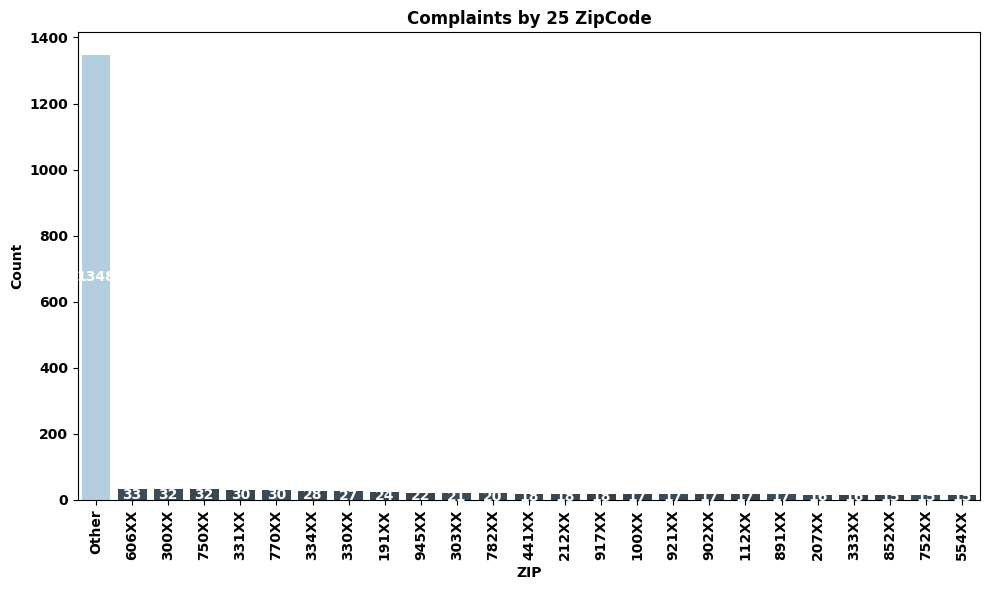

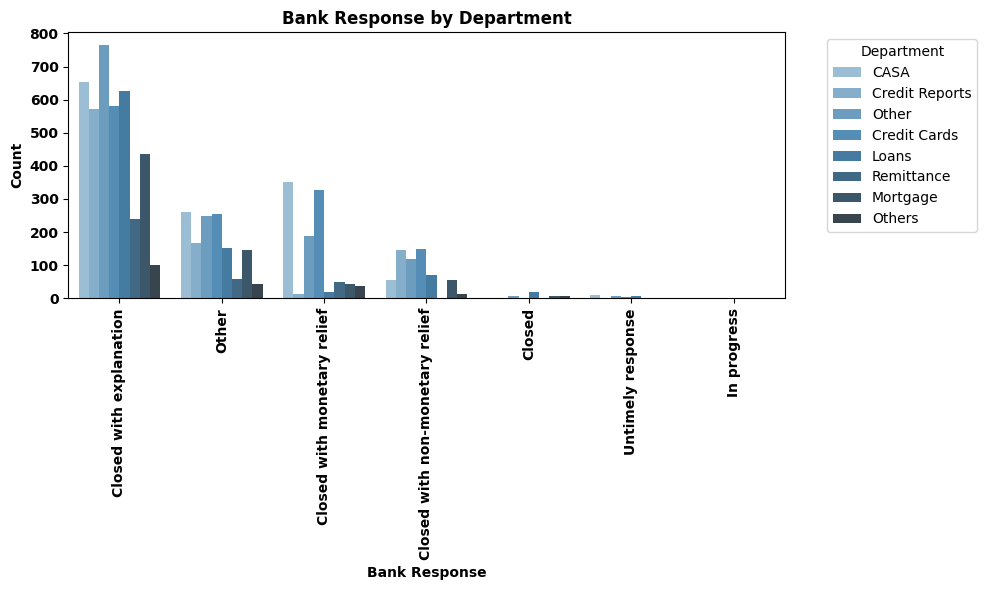

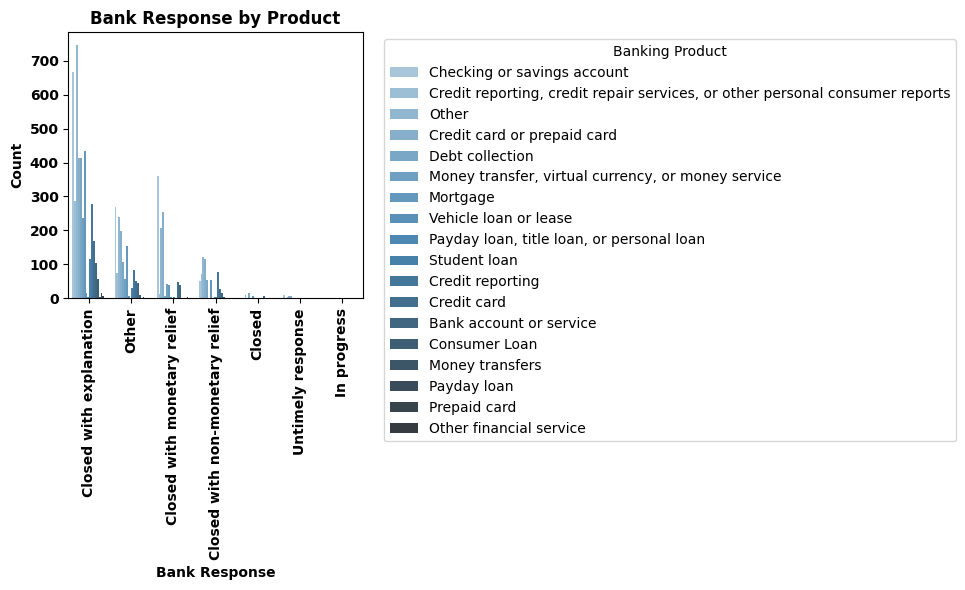

/tmp/ipykernel_40627/3983791333.py:94: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


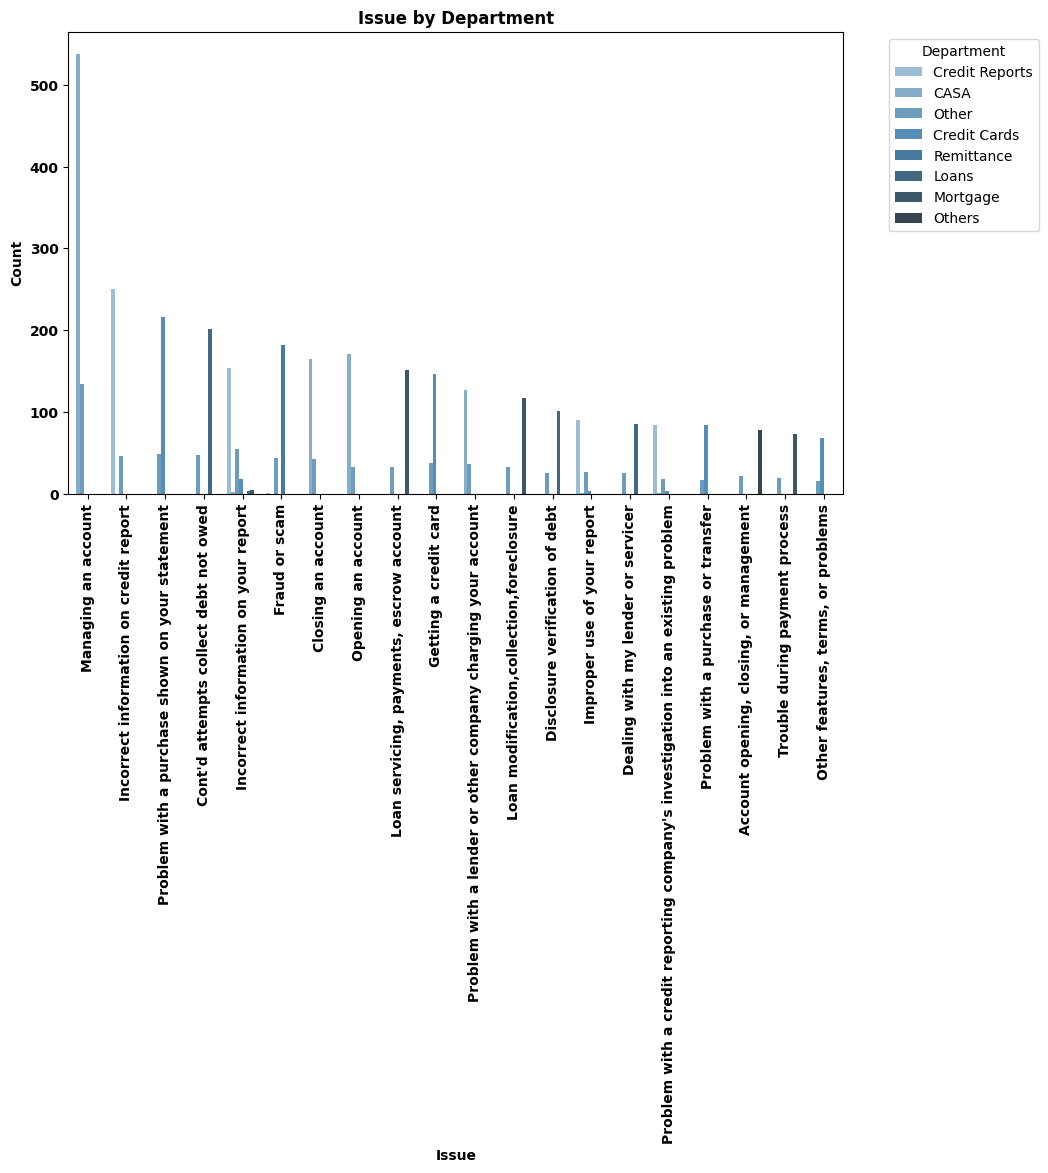

/tmp/ipykernel_40627/3983791333.py:94: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


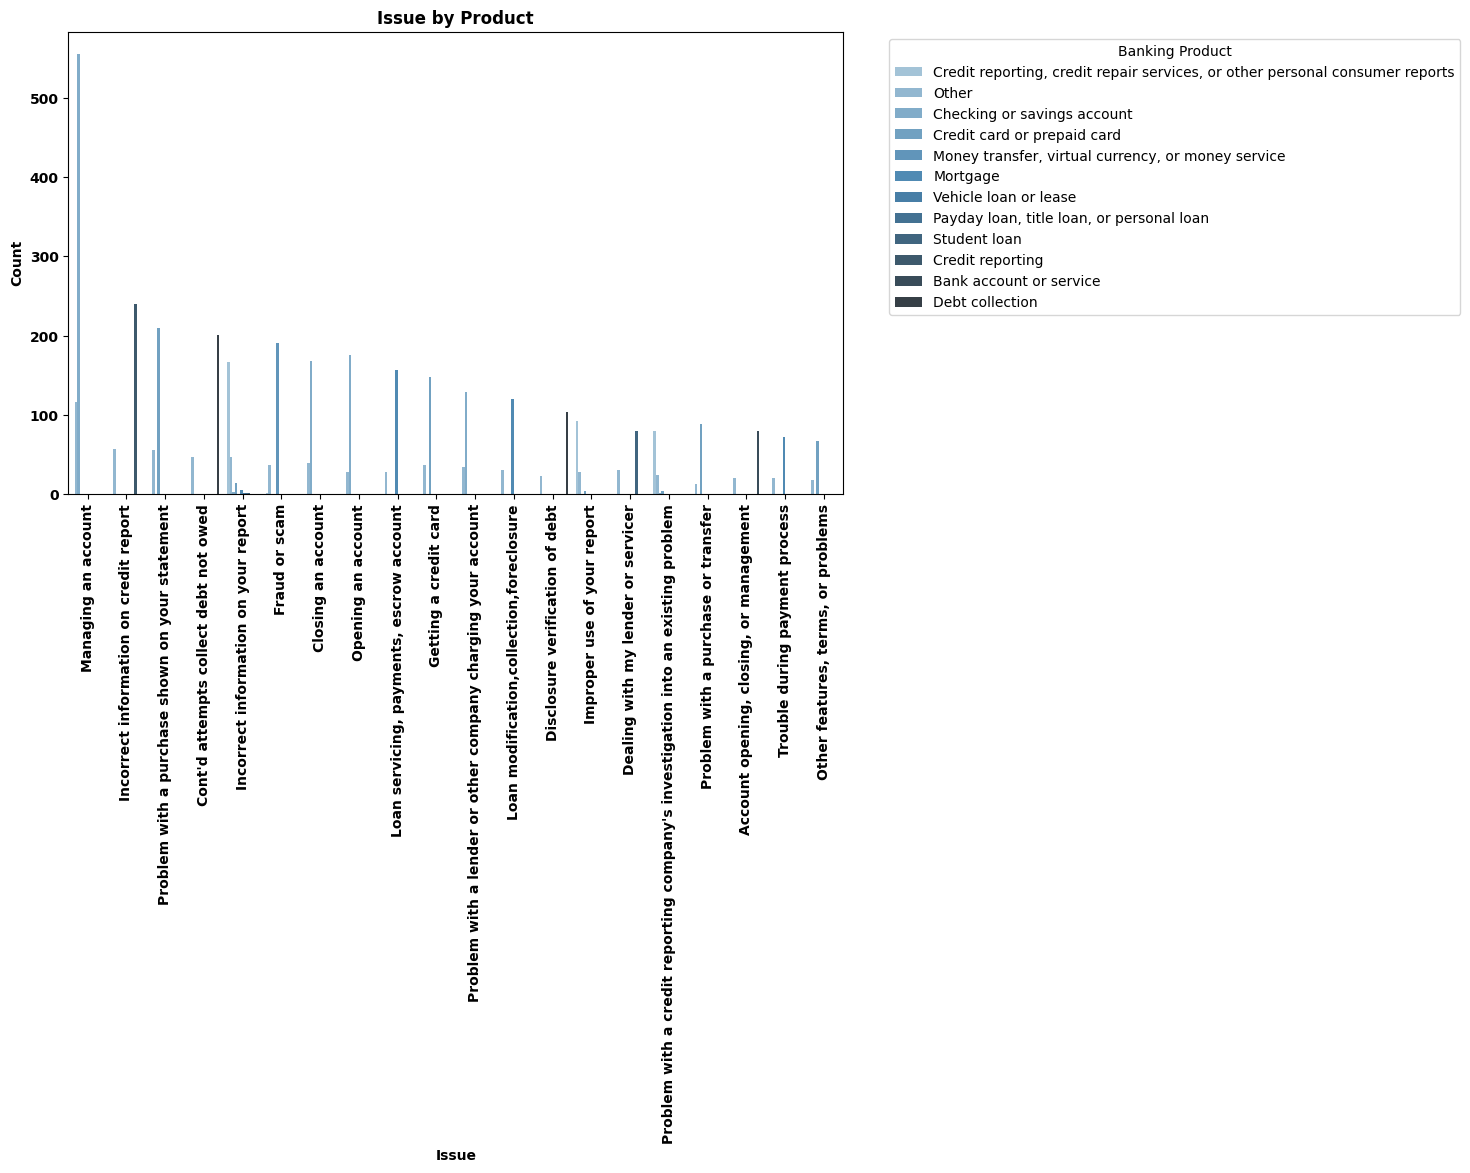

/tmp/ipykernel_40627/3983791333.py:94: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


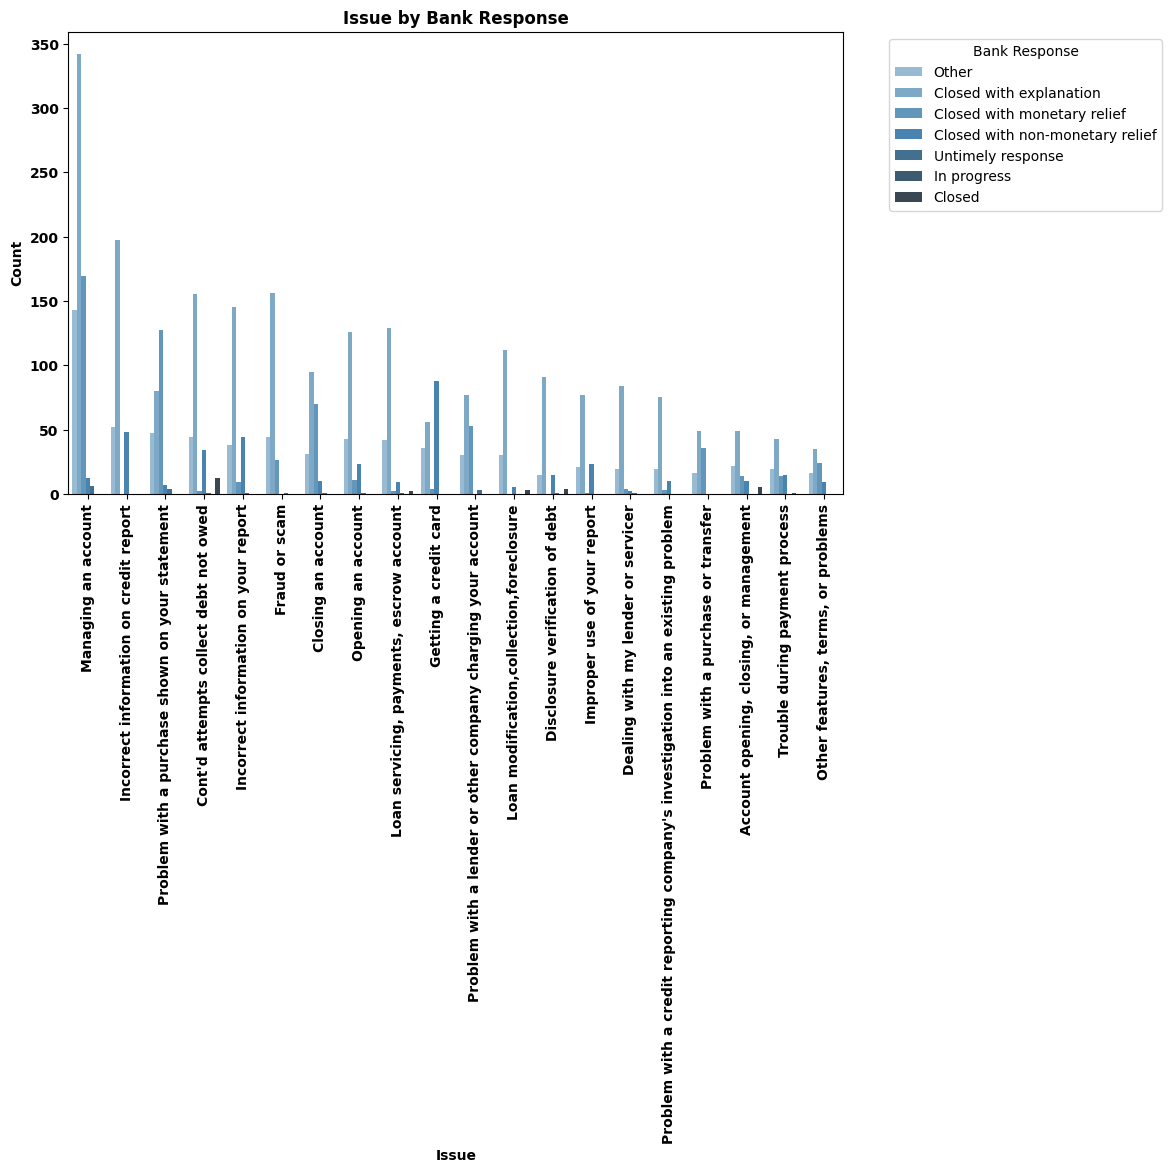

Complaints Date Range: 2023-01-01 00:00:00 to 2023-10-21 00:00:00


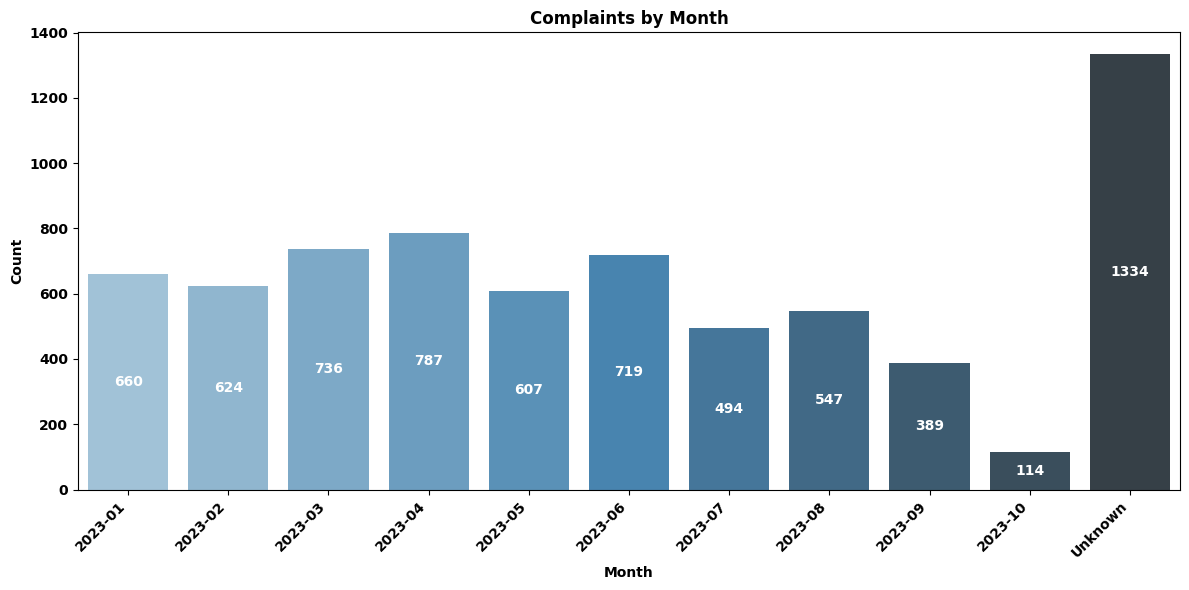

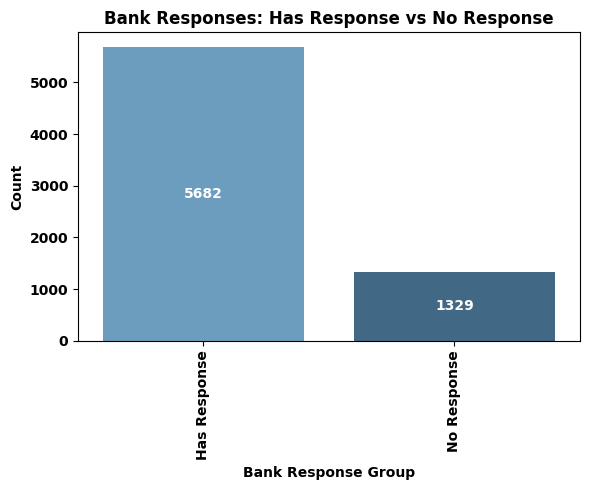

In [14]:
# Department Count Plot
departmentOrder = df_complaints_and_issues['Department'].unique().tolist()
DisplayCountPlot(df_complaints_and_issues, 'Department', departmentOrder, 'Complaints by Department', (10,6))

# Banking Products 
bankingProducts = df_complaints_and_issues['Banking Product'].unique().tolist()
DisplayCountPlot(df_complaints_and_issues, 'Banking Product', bankingProducts, 'Complaints by Banking Product', (10,6))

# State Distribution
states = df_complaints_and_issues['State'].value_counts().head(20).index.tolist()
DisplayCountPlot(df_complaints_and_issues, 'State', states, 'Complaints by Top 20 States', (10,6))

# Zip Codes
zipCodes = df_complaints_and_issues['ZIP'].value_counts().head(25).index.tolist()
DisplayCountPlot(df_complaints_and_issues, 'ZIP', zipCodes, 'Complaints by 25 ZipCode', (10,6))

# "Bank Response" by Department
DisplayGroupedCountPlot(df_complaints_and_issues, 'Bank Response', 'Department',  'Bank Response by Department', (10, 6))

# "Bank Response" by "Banking Product"
DisplayGroupedCountPlot(df_complaints_and_issues, 'Bank Response', 'Banking Product', 'Bank Response by Product', (10, 6))

# Issue by Department
DisplayGroupedCountPlot(df_complaints_and_issues, 'Issue', 'Department',      'Issue by Department', (10, 6), top_n=20)

# Issue by "Banking Product"
DisplayGroupedCountPlot(df_complaints_and_issues, 'Issue', 'Banking Product', 'Issue by Product', (10, 6), top_n=20)

# Issue by "Banking Response"
DisplayGroupedCountPlot(df_complaints_and_issues, 'Issue', 'Bank Response',   'Issue by Bank Response', (10, 6), top_n=20)


# Bin and plot complaints by month
print('=' * 60)
print(f"Complaints Date Range: {df_complaints_and_issues['Date Received'].min()} to {df_complaints_and_issues['Date Received'].max()}")
print('=' * 60)

# Deal with Nat by putting in default date 
df_complaints_and_issues['Date Received'] = df_complaints['Date Received'].fillna(pd.Timestamp('1900-01-01'))

# Create month bin column
df_complaints_and_issues['Month'] = df_complaints_and_issues['Date Received'].dt.to_period('M').astype(str)

# Create a meaningful label before binning
df_complaints_and_issues['Month'] = df_complaints_and_issues['Month'].replace('1900-01', 'Unknown')

# Aggregate counts per month
df_monthly = (df_complaints_and_issues
              .groupby('Month')
              .size()
              .reset_index(name='Count')
              .sort_values('Month'))

# Plot using your existing DisplayBarPlot function
DisplayBarPlot(df_monthly, 
               x_axis='Month', 
               y_axis='Count',
               x_axis_label='Month',
               y_axis_label='Count',
               plot_title='Complaints by Month')


# Plot all Bank Response values, colored by Blank vs Non-Blank status
df_complaints_and_issues['Bank Response Group'] = df_complaints_and_issues['Bank Response'].apply(
                                                                                                    lambda x: 'No Response' if x == 'Other' else 'Has Response'
                                                                                                )

status_order = ['Has Response', 'No Response']

DisplayCountPlot(df_complaints_and_issues,
                 'Bank Response Group',
                 status_order,
                 'Bank Responses: Has Response vs No Response',
                 (6, 5))        


#### EDA Plot Analysis
Analysis of distribution plots

- **Complaints by Department**
    - CASA, Credit Reports and Credit Cards have highest number of complaints
	- "Other" scores high too; customer service reps aren't following work flow/filling things out correctly/consistently
	- Remittance and Mortgage have lowest number of complaints
- **Complaints by Banking Products** 
    - Checking/Savings Account, Credit/prepaid Cards, Mortgage have highest number complaints
	- Other scores high again (see above for more info)
- **Complaints by States**
    - California, Florida, Texas, New York have highest number of complaints
	- Tenn, Nevada and S. Carolina have lowest number
	- Other scores high again (see above for more info)
	Is this evenly distributed based on state populations?
- **Complaints by Zip Codes**
    - Complaints seem to be evenly distributed across zip codes
	- Other scores high again (see above for more info)
- **Bank Response by Department**
    - **Closed** (with relief/explanation) is the highest scoring bank response across all departments
	- Other scores high again (see above for more info)
- **Bank Response by Banking Product**
	- **Closed** (with relief/non-relief/explanation) is the highest scoring bank response across all departments
	- Other scores high again (see above for more info)
- **Issues by Department**
    - Highest issues are:
		- Managing an account
		- Credit report errors
		- Monthly statement inaccuracies
		- Collection attempts
		- REport inaccuracies
		- Fraud/Scam
		- Opening/Closing an account
- **Issues by "Banking Product"**
    - Mirrors Issues by Department (See above)
- **Issues by "Banking Response"**
    - Account Management, Closed with Explanation response id the dominant issues
	- Followed by credit report inaccuracies with Close (non-relief) as response
- **Complaints by Month**
    - Peak months are March, April and June
	- A noticeable decrease (with slight August bump) from July to end of reporting period (October)
	- Other/Unknown scores high again (see above for more info)	
- **Bank Responses - Has Responses/No Responses**
    - Bank customer failed to respond to complaints 19% of the time
    - Is this part of their calculated business model? </br>
    Don't respond to a percentage of complaints hoping they just go away?

## 4.0 Data Wrangling/Preprocessing ##
#### Text Preprocessing Funtion ####
Apply text preprocessing to the "Complaint Description" to perform the following:
- Convert text to lowercase
- Handle numbers
- Remove stop-words
- Remove punctuation
- Apply **Beautiful Soup** library to remove HTML tags from text
- Apply lemmatization


</br>
BeautifulSoup added to preprocess_text() to remove 'HTML' tags from each review</br>
Slows preprocessing down, but more accurate than relying on RegEx()</br>

In [15]:
lemmatizer = WordNetLemmatizer()

# Preprocess function for full corpus
def preprocess_text(text, apply_lemmatization=True):

    # Probably more efficient way to do this, but this isn't a programming class.
    clean_text = BeautifulSoup(text, 'html.parser').get_text()

    tokens = word_tokenize(clean_text.lower())
    clean_tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

    if apply_lemmatization == True:
        # Lemmatization
        tokens_lemmatized = [lemmatizer.lemmatize(token) for token in clean_tokens]

        return tokens_lemmatized
    
    # otherwise return clean_tokens without lemmatization
    return clean_tokens


#### Explore Stemming and Lemmatization against sample Complaints data. ####

In [16]:
clean_tokens = df_complaints_and_issues['Complaint Description'].sample(50).apply(
                                                                lambda x: ' '.join(preprocess_text(x, apply_lemmatization=False))   
                                                            )

stemmer = PorterStemmer()

# Flatten all tokens into a single word list first
all_words = ' '.join(clean_tokens).split()

comparison_df = pd.DataFrame({
                                'original':   all_words[:50],
                                'stemmed':    [stemmer.stem(w) for w in all_words[:50]],
                                'lemmatized': [lemmatizer.lemmatize(w) for w in all_words[:50]]
                            })

comparison_df

,original,stemmed,lemmatized
0,ditech,ditech,ditech
1,served,serv,served
2,summons,summon,summons
3,foreclosure,foreclosur,foreclosure
4,fully,fulli,fully
5,aware,awar,aware
6,consumer,consum,consumer
7,finance,financ,finance
8,protection,protect,protection
9,bureau,bureau,bureau


#### Perform Text Preprocesssing ####

In [17]:
# Apply Text Preprocessing
# This produces comma separated tokens in a string...
#df_complaints_and_issues['Complaint Description Preprocessed'] = df_complaints_and_issues['Complaint Description'].apply(preprocess_text)
# join tokens with space, not comma
df_complaints_and_issues['Complaint Description Preprocessed'] = df_complaints_and_issues['Complaint Description'].apply(
                                                                            lambda x: ' '.join(preprocess_text(x))   
                                                                        )
#print(f'{df_complaints_and_issues["Complaint Description Preprocessed"].head(20)}')

#### 4.1 Word Frequency Analysis ####
Word frequency analysis across entire corpus.</br>

In [18]:
# Count word frequencies
def CountAndExamineWordFrequencies(target_text):
    word_freq = Counter(' '.join(target_text).split())

    # The number of unique words in the Dataset
    print("Number of unique words across all the reviews")
    print(f"Unique Words: {len(word_freq)}")

    # Display top words
    top_50 = word_freq.most_common(50)
    freq_df = pd.DataFrame(top_50, columns=['word', 'count'])
    print("Top 50 most frequent words")
    display(freq_df)

    # Display least frequent words
    print('Bottom 20 - least frequently used words')
    bottom_20 = sorted(word_freq.items(), key=lambda x: x[1])[:20]
    freq_df_bottom = pd.DataFrame(bottom_20, columns=['word', 'count'])
    display(freq_df_bottom)
    
    return word_freq

word_frequencies = CountAndExamineWordFrequencies(df_complaints_and_issues['Complaint Description Preprocessed'])

Number of unique words across all the reviews
Unique Words: 12945
Top 50 most frequent words


,word,count
0,xxxx,50949
1,bank,13046
2,account,12415
3,abc,7657
4,credit,7136
5,card,5323
6,payment,4455
7,would,4219
8,told,3784
9,time,3704


Bottom 20 - least frequently used words


,word,count
0,opener,1
1,reversible,1
2,propane,1
3,cooking,1
4,heating,1
5,beleived,1
6,pinterest,1
7,chged,1
8,propertyin,1
9,stateside,1


#### Word Frequency Analysis and Observations
In the top 50 most recently used words, I notice that '**xxxx**' occurs almost **51K times**.</br>
Upon further examination, '**xxxx**' is actually redacted text and has no contextual meaning in the reviews.</br>
It should be removed from '**Complaint Descriptions'** because it really is a form of noise.

Upon Looking over the list of least frequently used words, I noticed several obvious spelling mistakes:</br>
- beleived
- specdify
- deays
- crovable

#### 4.2 Identify the Unknown Words ####
I would like to examine the entire corpus and identify any unknown/unrecognized words and their frequency. </br>
Some of these words might be slangs, some might be legitimate misspellings. </br>
With 70K-ish tokens this shouldn't be a heavy lift.</br>
Once examining the results, I can make a strategy (if any) to deal with unknown/misspelled words.</br>
We're not going to worry about punctuation correctness as punctuation will get filtered out through pre-processing. </br>
</br>
Surprisingly, there are over 26K unknown words in the tokens.</br>
Before deciding whether or not I'm just chasing down a potential rabbit hole, examine the following:</br>
- Most common unknown words
- Middle common unknown words
- Least common unknown words


In [19]:
def UnknownWordAnalysis(target_text):
    
    spell_checker = SpellChecker()
    all_unique_words = list(target_text.keys())
    unknown_words = spell_checker.unknown(all_unique_words)
    print(f"Number of Unique Unknown Words: {len(unknown_words)}")

    # Get frequency of unknown word instances
    unknown_freqs = [(word, target_text[word]) for word in unknown_words]
    unknown_freqs.sort(key=lambda x: x[1], reverse=True)

    # Words occurring over 100 times
    most_common_unknown_words = [item for item in unknown_freqs if item[1] > 100]
    print(f"Words occurring more than 100 times: (Total {len(most_common_unknown_words)}) ---")
    print('\n'.join(f"  {word}: {count}" for word, count in most_common_unknown_words[:100]))

    # Words occurring between 5 and 10 times
    middle_used_unknown_words = [item for item in unknown_freqs if 5 <= item[1] <= 10]
    print(f"Words occurring between 5 and 10 times: (Total {len(middle_used_unknown_words)}) ---")
    print('\n'.join(f"  {word}: {count}" for word, count in middle_used_unknown_words[:50]))

    # Words appearing only once
    least_common_unknown_words = [item for item in unknown_freqs if item[1] == 1]
    print(f"50 least common unknown words (Total {len(least_common_unknown_words)}) ---")
    print('\n'.join(f"  {word}: {count}" for word, count in least_common_unknown_words[:100]))

UnknownWordAnalysis(word_frequencies)


Number of Unique Unknown Words: 2955
Words occurring more than 100 times: (Total 31) ---
  xxxx: 50949
  abc: 7657
  bofa: 1134
  xx: 673
  xxxxxxxx: 558
  atm: 450
  cfpb: 438
  im: 368
  dont: 333
  didnt: 315
  app: 276
  equifax: 274
  usc: 254
  ive: 222
  dept: 184
  fcra: 183
  experian: 173
  etc: 168
  edd: 162
  transunion: 157
  navient: 156
  scammer: 145
  nationstar: 134
  ftc: 131
  irs: 128
  acct: 128
  servicer: 125
  citi: 125
  covid: 113
  cc: 107
  ocwen: 103
Words occurring between 5 and 10 times: (Total 139) ---
  withdrawl: 10
  pst: 10
  hoa: 10
  uas: 10
  mortage: 10
  birthdate: 10
  cras: 10
  acount: 10
  dl: 10
  seq: 10
  qwr: 10
  weve: 10
  respa: 10
  forclosure: 10
  fradulent: 10
  comp: 10
  ssi: 10
  ppp: 10
  ols: 9
  sps: 9
  recieving: 9
  hippa: 9
  erc: 9
  gmac: 9
  bc: 9
  onboard: 9
  everbank: 9
  dmv: 9
  cheque: 9
  xxxxbank: 8
  financials: 8
  hsa: 8
  nv: 8
  ncc: 8
  citigold: 8
  zelle: 8
  pslf: 8
  ie: 8
  hfc: 8
  abcns: 8
  wf

#### Unique Word Discovery Analysis
Initial examination reveals words containing ('xx') in succession. </br>
To me this looks like some form of redacted text (as mentioned above). </br>
Based on findings I'd like to extend the initial to remove all words containing or having embedded 'xx' </br>

A quick look at a sampling of the most, average, least number of unknown words.</br>
Based on the output, it looks like all of these are legitimate words coming under the following types:
- slangs
- acronyms 
- abbreviations
- proper names</br>

</br>
Based on that, we can keep the unknown words as part of the overall tokenized corpus as they do carry weight/meaning in the review.

In [20]:
# Remove words with embedded 'xx' characters
def remove_xx_words(text):
    words = text.split()
    cleaned = [word for word in words if 'xx' not in word]
    return ' '.join(cleaned)

df_complaints_and_issues['Complaint Description Preprocessed'] = \
    df_complaints_and_issues['Complaint Description Preprocessed'].apply(remove_xx_words)

#### 4.3 Re-Examine Unique and Unknown Words ####

In [21]:
word_frequencies = CountAndExamineWordFrequencies(df_complaints_and_issues['Complaint Description Preprocessed'])
UnknownWordAnalysis(word_frequencies)

Number of unique words across all the reviews
Unique Words: 12750
Top 50 most frequent words


,word,count
0,bank,13046
1,account,12415
2,abc,7657
3,credit,7136
4,card,5323
5,payment,4455
6,would,4219
7,told,3784
8,time,3704
9,money,3354


Bottom 20 - least frequently used words


,word,count
0,opener,1
1,reversible,1
2,propane,1
3,cooking,1
4,heating,1
5,beleived,1
6,pinterest,1
7,chged,1
8,propertyin,1
9,stateside,1


Number of Unique Unknown Words: 2760
Words occurring more than 100 times: (Total 28) ---
  abc: 7657
  bofa: 1134
  atm: 450
  cfpb: 438
  im: 368
  dont: 333
  didnt: 315
  app: 276
  equifax: 274
  usc: 254
  ive: 222
  dept: 184
  fcra: 183
  experian: 173
  etc: 168
  edd: 162
  transunion: 157
  navient: 156
  scammer: 145
  nationstar: 134
  ftc: 131
  irs: 128
  acct: 128
  servicer: 125
  citi: 125
  covid: 113
  cc: 107
  ocwen: 103
Words occurring between 5 and 10 times: (Total 134) ---
  withdrawl: 10
  pst: 10
  hoa: 10
  uas: 10
  mortage: 10
  birthdate: 10
  cras: 10
  acount: 10
  dl: 10
  seq: 10
  qwr: 10
  weve: 10
  respa: 10
  forclosure: 10
  fradulent: 10
  comp: 10
  ssi: 10
  ppp: 10
  ols: 9
  sps: 9
  recieving: 9
  hippa: 9
  erc: 9
  gmac: 9
  bc: 9
  onboard: 9
  everbank: 9
  dmv: 9
  cheque: 9
  financials: 8
  hsa: 8
  nv: 8
  ncc: 8
  citigold: 8
  zelle: 8
  pslf: 8
  ie: 8
  hfc: 8
  abcns: 8
  wf: 8
  vmrp: 8
  mcm: 8
  bein: 8
  wyndham: 8
  doj: 8

#### 4.4 Spelling Examination and Analysis

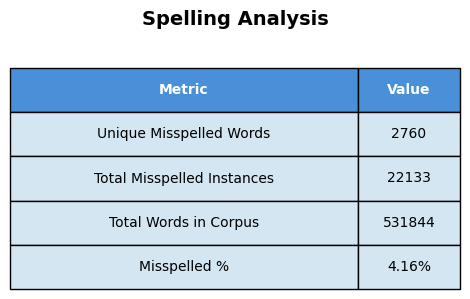




Top 20 most frequently misspelled words:


,word,count
0,abc,7657
1,bofa,1134
2,atm,450
3,cfpb,438
4,im,368
5,dont,333
6,didnt,315
7,app,276
8,equifax,274
9,usc,254


In [22]:
spell_checker = SpellChecker()

all_words = ' '.join(df_complaints_and_issues['Complaint Description Preprocessed']).split()

# Get unique unknown words
unknown_unique = spell_checker.unknown(all_words)

# Count frequency of each misspelled word
unknown_freq = Counter(word for word in all_words if word in unknown_unique)

# print(f"Unique misspelled words:          {len(unknown_unique)}")
# print(f"Total misspelled word instances:  {sum(unknown_freq.values())}")
# print(f"Total words in corpus:            {len(all_words)}")
# print(f"Misspelled %:                     {sum(unknown_freq.values()) / len(all_words) * 100:.2f}%")

df_spelling_summary = pd.DataFrame({
                                    'Metric': ['Unique Misspelled Words', 'Total Misspelled Instances', 'Total Words in Corpus', 'Misspelled %'],
                                    'Value':  [len(unknown_unique), sum(unknown_freq.values()), len(all_words), 
                                            f"{sum(unknown_freq.values()) / len(all_words) * 100:.2f}%"]
                                })

DisplayTable(df_spelling_summary, 'Spelling Analysis')

# Top frequently misspelled words
print("\nTop 20 most frequently misspelled words:")
display(pd.DataFrame(unknown_freq.most_common(20), columns=['word', 'count']))

#### Spelling Analysis ####
A quick look at the identified '**misspelled words'** and the patterns closely follow those of the frequently used unique words.</br>
It looks like all of these are legitimate (slangs, acronyms, abbr and proper names.)</br>
Based on that, we can keep these words as part of the overall corpus.</br>

#### 4.5 Examination of Complaint Description Lengths

Review Length Analysis Results

Average Review Length: 956.37
Average Word Count per Review: 176.47



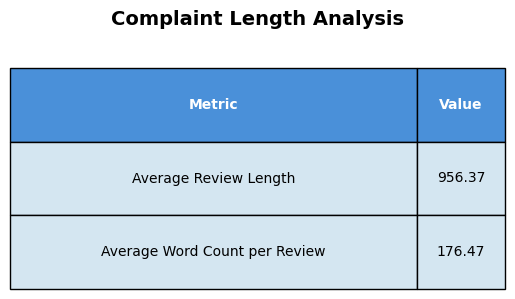

In [23]:

# Average character length of a complaint
average_review_length = df_complaints_and_issues['Complaint Description'].str.len().mean()

# Calculate average number of words per review
average_review_word_count = df_complaints_and_issues['Complaint Description'].str.split().str.len().mean()

print('============================================================================')
print('Review Length Analysis Results')
print()
print(f'Average Review Length: {average_review_length:.2f}')
print(f'Average Word Count per Review: {average_review_word_count:.2f}')
print()
print('============================================================================')


df_complaint_length = pd.DataFrame({
                                    'Metric': ['Average Review Length', 'Average Word Count per Review'],
                                    'Value':  [f'{average_review_length:.2f}', f'{average_review_word_count:.2f}']
                                })

DisplayTable(df_complaint_length, 'Complaint Length Analysis')


#### Observations of Complaint Description Lengths
This was more a point of curiosity rather than having any real mean at this point. </br>
It would have more meaning if we looked at the breakdown of review lengths vs Product/Department </br>
Once Sentiment Analysis has been applied, it might be interesting to look at the relationship between </br>
positive/negative sentiments and review length </br>
The model choices for the classification do not require padding, so length is kind of a moot point.</br>
#### 4.6 Word Cloud Visualization

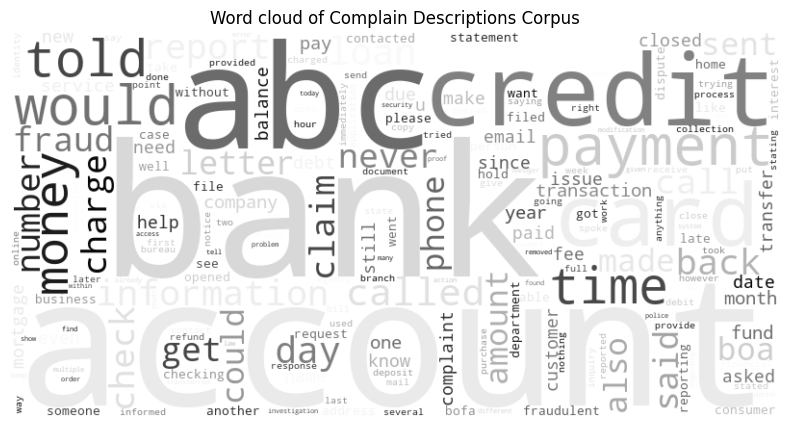

In [24]:
# Create word cloud
wordcloud = WordCloud(
                        width=800,
                        height=400,
                        background_color='white',
                        colormap='Greys'
                    ).generate_from_frequencies(word_frequencies)

plt.figure(figsize=(10, 5))
plt.title('Word cloud of Complain Descriptions Corpus')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

#### 4.7 Word Frequency Distribution

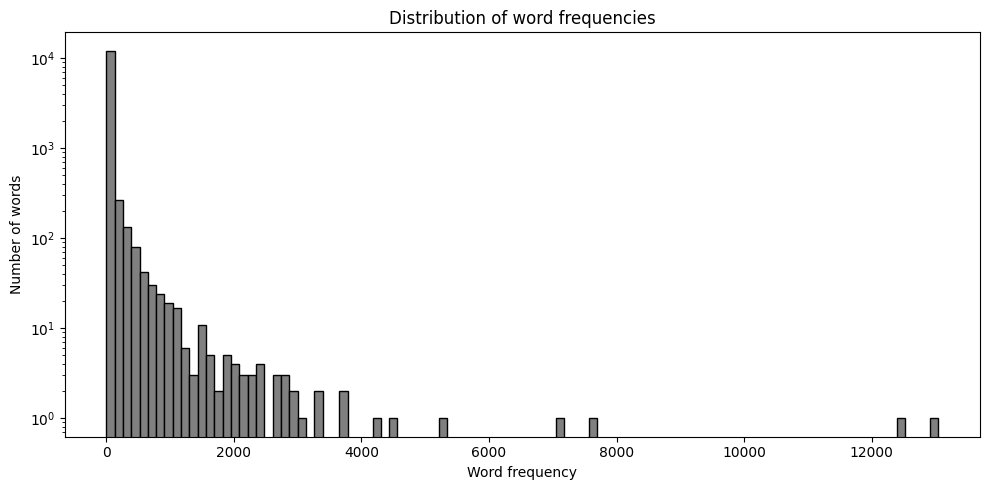

In [25]:
# Histogram of word frequency distribution
word_counts = list(word_frequencies.values())

plt.figure(figsize=(10, 5))
plt.title('Distribution of word frequencies')
plt.hist(word_counts, bins=100, color='grey', edgecolor='black')
plt.xlabel('Word frequency')
plt.ylabel('Number of words')
plt.yscale('log')  # Use logarithmic scale for better visibility
plt.tight_layout()
plt.show()

#### Word Frequency Observations
- 1 word appears almost 100k times
- Top 2 words = bank, account (??)
    - Not entirely clear how that could affect sentiment or predict product/department
- Heavy Right-Skewed - a small number of words occur many times (dominant)
</br>

## 5.0 TF-IDF Matrix Features ##
Convert the pre-processed text into a matrix of TF-IDF features for downstream modelling.</br>

#### 5.1 Deal with Blank Complaint Description Values ####
</br>
**Question** If there are blank complaints, how can we possibly try to classify the into the correct Department? </br>
It is be better to just drop those columns altogether, for fear they'll cause issues further on during processing/analysis

#### Count the rows with empty descriptions

In [26]:

# Count the description strings where it either Nan or Empty strings
empty_count = (df_complaints_and_issues['Complaint Description Preprocessed'].isna().sum() + 
               df_complaints_and_issues['Complaint Description Preprocessed'].str.strip().eq('').sum())

print(f"Number of Empty/NaN descriptions: {empty_count}")

Number of Empty/NaN descriptions: 1330


#### Drop data rows with Empty/Nan Complaint Descriptions

In [27]:
print(f"Total Rows in Complaints and Issues Dataset: {len(df_complaints_and_issues)}")

df_complaints_and_issues = df_complaints_and_issues.dropna(subset=['Complaint Description Preprocessed'])
df_complaints_and_issues = df_complaints_and_issues[df_complaints_and_issues['Complaint Description Preprocessed'].str.strip() != '']

print(f"Rows remaining: {len(df_complaints_and_issues)}")

Total Rows in Complaints and Issues Dataset: 7011
Rows remaining: 5681


#### 5.2 Train-Validate-Test Split
To prevent data leakage, we'll proceed to split the dataset into 3 sections (as usual):
- Training Dataset
- Validation Dataset
- Testing Dataset</br>

The target models we will be training/test/evaluating are:
1. MultinomialNB
2. LinearSVC
3. LogisticRegression</br>
</br>

With a relatively small dataset and Complaint Descriptions a **DDL** like **LSTM** would be overkill.</br>
So I decided to use smaller/simpler models for this task. </br>

All 3 of these models can handle string labels. </br>
For simplification and ease of implementation we will leave the Departments as strings </br>
</br>

Train/Test Split</br>
Vectorize (Fit&Transform, Transform) the splits using **TfidfVectorizer**</br>
Use GridSearchCV() for hyperparameter and tuning and validation, so there's no need to hold out a separate validation split.

In [28]:
X = df_complaints_and_issues['Complaint Description Preprocessed']
y = df_complaints_and_issues['Department']

# Step 1: Split into Train (70%) and a temporary set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Initialize the vectorizer
tfidf = TfidfVectorizer(max_features=5000) 

# Step 4: The actual Vectorization
X_train_tfidf = tfidf.fit_transform(X_train)  # Learns AND transforms
X_test_tfidf = tfidf.transform(X_test)        # Transform Only

### 5.3 Naive Bayes Model
Use Grid search to find the best hyperparameter combination.</br></br>
**Parameters**</br>
The only hyperparameter to tune for grid search is "**alpha**" </br>
</br>
**[From Online Research]**
Alpha ($\alpha$) is a smoothing parameter that adds a small "fake" count to every word in the dataset</br>
to ensure that no probability ever becomes zero, which would otherwise break the model's math

In [29]:
classification_results = {}

# Parameters
nb_param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 10.0]}

# Setup the Grid Search
model = MultinomialNB()
nb_grid_search = GridSearchCV(model, 
                              nb_param_grid, 
                              cv=5) 

# Run
nb_grid_search.fit(X_train_tfidf, y_train)

# Results
print(f"Best Internal Validation Accuracy: {nb_grid_search.best_score_:.3f}")
print(f"Best Parameters: {nb_grid_search.best_params_}")

# "Best Estimator" for the final test
best_nb_model = nb_grid_search.best_estimator_

# Predictions
train_predictions = best_nb_model.predict(X_train_tfidf)
y_test_pred = best_nb_model.predict(X_test_tfidf)

# Probability scores
y_test_prob = best_nb_model.predict_proba(X_test_tfidf)

# Final Evaluation
print(f'Final Test Accuracy: {accuracy_score(y_test, y_test_pred):.3f}')

# Metrics
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy  = accuracy_score(y_test, y_test_pred)
test_f1        = f1_score(y_test, y_test_pred, average='weighted')
roc_auc        = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')

report = classification_report(y_test, y_test_pred, output_dict=True)

nb_results =  { 'model':            best_nb_model,
                'train_accuracy':   train_accuracy,
                'test_accuracy':    test_accuracy,
                'f1_score':         test_f1,
                'roc_auc':          roc_auc,
                'y_test_prob':      y_test_prob,
                'X_train':          X_train_tfidf,
                'X_test':           X_test_tfidf,
                'y_train':          y_train,
                'y_test':           y_test, 
                'test_predictions': y_test_pred,
                'report':           report
            }

classification_results['Naive Bayes'] = nb_results

Best Internal Validation Accuracy: 0.538
Best Parameters: {'alpha': 0.1}
Final Test Accuracy: 0.548


### 5.4 Linear SVC Model
Use Grid search to find the best hyperparameter combination.</br>
LinearSVC does not support predict_proba() — requires CalibratedClassifierCV wrapper. [Based on research Claude/Gemini]</br></br>
**Parameters**</br>
- C
    - Strictness, ignores noise 0.1 (less strict) - 100 (high strictness)
- Loss
    - Penalty/Error during training
</br>


In [30]:
# Parameters
svc_param_grid = {
                    'estimator__C': [0.1, 1, 10, 100],
                    'estimator__loss': ['hinge', 'squared_hinge']
                }

# Setup the Grid Search — wrapped with CalibratedClassifierCV for predict_proba support
svc_grid_search = GridSearchCV(CalibratedClassifierCV(LinearSVC(random_state=42)), 
                                                      svc_param_grid, 
                                                      cv=5)

# Run
svc_grid_search.fit(X_train_tfidf, y_train)

# Results
print(f"Best C value: {svc_grid_search.best_params_}")
print(f"Best Validation Accuracy: {svc_grid_search.best_score_:.3f}")

# Evaluate on the final Test Set
best_svc_model = svc_grid_search.best_estimator_

# Predictions
train_predictions = best_svc_model.predict(X_train_tfidf)    
y_test_pred       = best_svc_model.predict(X_test_tfidf)

# Probability scores
y_test_prob = best_svc_model.predict_proba(X_test_tfidf)

print(f"Final Test Accuracy: {accuracy_score(y_test, y_test_pred):.3f}")

# Metrics
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy  = accuracy_score(y_test, y_test_pred)
test_f1        = f1_score(y_test, y_test_pred, average='weighted')
roc_auc        = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')

report = classification_report(y_test, y_test_pred, output_dict=True)

svc_results =  { 'model':            best_svc_model,
                 'train_accuracy':   train_accuracy,
                 'test_accuracy':    test_accuracy,
                 'f1_score':         test_f1,
                 'roc_auc':          roc_auc,
                 'y_test_prob':      y_test_prob,
                 'X_train':          X_train_tfidf,
                 'X_test':           X_test_tfidf,
                 'y_train':          y_train,
                 'y_test':           y_test,
                 'test_predictions': y_test_pred,
                 'report':           report
            }

classification_results['Linear SVC'] = svc_results

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_classes.py:31: Futu

Best C value: {'estimator__C': 0.1, 'estimator__loss': 'squared_hinge'}
Best Validation Accuracy: 0.603
Final Test Accuracy: 0.598


### 5.5 Logistic Regression Model
Use Grid search to find the best hyperparameter combination.</br></br>
**Parameters**</br>
- C
    - Strictness, ignores noise 0.1 (less strict) - 100 (high strictness)
- penalty
    - Penalty/Error during training
- solver 
</br>


In [31]:
# Parameters
lr_param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear works well with l1 and l2
}

# Setup the Grid Search
lr_grid_search = GridSearchCV(LogisticRegression(random_state=42), 
                              lr_param_grid, 
                              cv=5)

# Run
lr_grid_search.fit(X_train_tfidf, y_train)

# Results
print(f"Best LR Params: {lr_grid_search.best_params_}")
print(f"Best Validation Accuracy: {lr_grid_search.best_score_:.3f}")

# Final Evaluation on Test Set
best_lr_model = lr_grid_search.best_estimator_

# Predictions
train_predictions = best_lr_model.predict(X_train_tfidf)
y_test_pred       = best_lr_model.predict(X_test_tfidf)

# Probability scores
y_test_prob = best_lr_model.predict_proba(X_test_tfidf)

# Final Evaluation
print(f'Final Test Accuracy: {accuracy_score(y_test, y_test_pred):.3f}')

# Metrics
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy  = accuracy_score(y_test, y_test_pred)
test_f1        = f1_score(y_test, y_test_pred, average='weighted')
roc_auc        = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')

report = classification_report(y_test, y_test_pred, output_dict=True)

lr_results =  { 'model':            best_lr_model,
                'train_accuracy':   train_accuracy,
                'test_accuracy':    test_accuracy,
                'f1_score':         test_f1,
                'roc_auc':          roc_auc,
                'y_test_prob':      y_test_prob,
                'X_train':          X_train_tfidf,
                'X_test':           X_test_tfidf,
                'y_train':          y_train,
                'y_test':           y_test,
                'test_predictions': y_test_pred,
                'report':           report
            }

classification_results['Logistic Regression'] = lr_results

Best LR Params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Validation Accuracy: 0.580
Final Test Accuracy: 0.581


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   ### 5.6 Pre-trained DistilBERT model from HuggingFace using Transformers
   BERT models can take a **LONG TIME** to run and I'm currently still using a CPU. </br>
   **DistilBERT** is a smaller, faster, and cheaper version of the BERT model and more suited to on a CPU.</br>
   </br>
   In an effort not to crash/corrupt this note book and lose all the previous LSTM-CNN results, I implemented, </br>
   debugged and tested the **DistilBERT** model in a separate test notebook using a subset of the corpus. </br>
   In addition I reduced the max_length and slimmed down the hyperparameter values in addition to epochs. </br>
   Once I felt confident this was working I added here using full corpus and hyperparameter values </br>   

   #### DistiliBERT Runtime Performance     

In [32]:
# For Tracking Notebook runtime/performance
distilbert_start_time = time.time()

#### DistilBERT Hyperparameters

In [33]:
# Hyperparameters for Debugging:
# bert_learning_rates = [2e-5]
# bert_batch_sizes    = [16]
# bert_epochs         = 2
# bert_thresholds     = [0.4, 0.5]

# Hyperparameters for for 7Kish rows of data
bert_learning_rates = [2e-5]
bert_batch_sizes    = [16, 32]
bert_epochs         = 3

debug_datasample_size = None

#### DistilBERT Utility Functions
These were taken directly from Capstone 13 with some small modifications so that results can </br>
be comparable against the other Classification Models. 

In [34]:
def preprocess_text_for_bert(text):
    clean_text = BeautifulSoup(text, 'html.parser').get_text()
    return clean_text

#def TokenizeForBert(texts, max_length=64):
def TokenizeForBert(texts, max_length=128):
    # Ensure all texts are clean strings before tokenizing
    clean_texts = [str(t) if t is not None else '' for t in texts]
    return bert_tokenizer(
        clean_texts,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors='np'
    )

def TuneAndEvaluateDistilBERT(X_train_bert, y_train,
                               X_val_bert,   y_val,
                               X_test_bert,  y_test,
                               num_labels,
                               learning_rates, batch_sizes,
                               epochs=3):

    model_name = 'DistilBERT'

    print('=================================================================================================')
    print(f'Evaluating Model: {model_name}')

    total_combinations = len(learning_rates) * len(batch_sizes)
    print(f'Total hyperparameter combinations: {total_combinations}')

    checkpoint_path = f'models/checkpoint_{model_name}.weights.h5'

    early_stopping = EarlyStopping(
                                    monitor='val_loss',
                                    patience=2,
                                    restore_best_weights=True
                                )

    checkpoint = ModelCheckpoint(
                                    filepath=checkpoint_path,
                                    monitor='val_loss',
                                    save_best_only=True,
                                    save_weights_only=True,
                                    verbose=1
                                )

    tuning_results = []
    combo_num      = 0
    best_val_f1    = -1
    best_result    = None
    best_weights   = None
    best_history   = None

    for learning_rate, batch_size in product(learning_rates, batch_sizes):

        combo_num += 1
        print(f'Combo {combo_num} learning_rate={learning_rate} batch={batch_size}')

        model = TFDistilBertForSequenceClassification.from_pretrained(
                                                                        'distilbert-base-uncased',
                                                                        num_labels=num_labels
                                                                    )

        model.compile(
                        optimizer=Adam(learning_rate=learning_rate),
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                        metrics=['accuracy']
                    )

        history = model.fit(
                    {'input_ids':      X_train_bert['input_ids'],
                     'attention_mask': X_train_bert['attention_mask']},
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(
                                        {'input_ids':      X_val_bert['input_ids'],
                                         'attention_mask': X_val_bert['attention_mask']},
                                        y_val
                                    ),
                    callbacks=[early_stopping, checkpoint],
                    verbose=1
                )

        final_loss     = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]

        # Validation predictions
        logits    = model.predict(
                        {'input_ids':      X_val_bert['input_ids'],
                         'attention_mask': X_val_bert['attention_mask']}
                    ).logits
        val_probs  = tf.nn.softmax(logits, axis=-1).numpy()
        y_pred_val = np.argmax(val_probs, axis=-1)

        val_f1       = f1_score(y_val, y_pred_val, average='weighted', zero_division=0)
        val_accuracy = accuracy_score(y_val, y_pred_val)

        tuning_results.append({
                                'model_name':    model_name,
                                'run':           combo_num,
                                'learning_rate': learning_rate,
                                'batch_size':    batch_size,
                                'loss':          final_loss,
                                'val_loss':      final_val_loss,
                                'val_accuracy':  val_accuracy,
                                'val_precision': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                                'val_recall':    recall_score(y_val,    y_pred_val, average='weighted', zero_division=0),
                                'val_f1':        val_f1,
                            })

        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_weights = model.get_weights()
            best_history = history.history
            best_result  = {
                                'model_name':    model_name,
                                'best_run':      combo_num,
                                'learning_rate': learning_rate,
                                'batch_size':    batch_size,
                                'loss':          final_loss,
                                'val_loss':      final_val_loss,
                                'val_accuracy':  val_accuracy,
                                'val_precision': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                                'val_recall':    recall_score(y_val,    y_pred_val, average='weighted', zero_division=0),
                                'val_f1':        val_f1,
                            }
            print(f'  *** New best — Run {combo_num} — F1: {val_f1:.4f} ***')

    # ── Tuning Summary ────────────────────────────────────────────────────────
    df_tuning = pd.DataFrame(tuning_results)
    print(f'======================================================================')
    print(f'{model_name} Tuning Results')
    print(f'======================================================================')
    print(df_tuning.sort_values('val_f1', ascending=False).to_string())

    print(f'======================================================================')
    print(f'{model_name} Best Hyperparameters')
    print(f'======================================================================')
    print(f'Best Run      : {best_result["best_run"]} of {total_combinations}')
    print(f'learning_rate : {best_result["learning_rate"]}')
    print(f'batch_size    : {best_result["batch_size"]}')
    print(f'Loss          : {best_result["loss"]:.4f}')
    print(f'Val Loss      : {best_result["val_loss"]:.4f}')
    print(f'Validation F1 : {best_result["val_f1"]:.4f}')
    print(f'Checkpoint    : {checkpoint_path}')
    print()

    # ── Restore Best Weights ──────────────────────────────────────────────────
    best_model = TFDistilBertForSequenceClassification.from_pretrained(
                    'distilbert-base-uncased',
                    num_labels=num_labels
                 )
    best_model.compile(
                        optimizer=Adam(learning_rate=best_result['learning_rate']),
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                        metrics=['accuracy']
                    )

    best_model.predict(
        {'input_ids':      X_train_bert['input_ids'][:1],
         'attention_mask': X_train_bert['attention_mask'][:1]},
        verbose=0
    )
    best_model.set_weights(best_weights)

    # ── Final Test Evaluation ─────────────────────────────────────────────────
    logits      = best_model.predict(
                        {'input_ids':      X_test_bert['input_ids'],
                         'attention_mask': X_test_bert['attention_mask']}
                  ).logits
    test_probs  = tf.nn.softmax(logits, axis=-1).numpy()
    y_pred_test = np.argmax(test_probs, axis=-1)

    # ── Train Predictions ─────────────────────────────────────────────────────
    train_logits   = best_model.predict(
                         {'input_ids':      X_train_bert['input_ids'],
                          'attention_mask': X_train_bert['attention_mask']}
                     ).logits
    train_probs    = tf.nn.softmax(train_logits, axis=-1).numpy()
    y_pred_train   = np.argmax(train_probs, axis=-1)
    train_accuracy = accuracy_score(y_train, y_pred_train)

    # ── Metrics ───────────────────────────────────────────────────────────────
    test_accuracy = accuracy_score(y_test,  y_pred_test)
    test_f1       = f1_score(y_test,        y_pred_test, average='weighted', zero_division=0)
    roc_auc       = roc_auc_score(y_test,   test_probs,  multi_class='ovr',  average='weighted')
    report        = classification_report(y_test, y_pred_test, output_dict=True)

    best_weights_path = f'models/best_{model_name}.weights.h5'
    best_model.save_weights(best_weights_path)
    print(f'Best weights saved: {best_weights_path}')

    print(f'======================================================================')
    print(f'{model_name} Final Test Set Results')
    print(f'======================================================================')
    print(f'Best Run  : {best_result["best_run"]} of {total_combinations}')
    print(f'Accuracy  : {test_accuracy:.4f}')
    print(f'Precision : {precision_score(y_test, y_pred_test, average="weighted", zero_division=0):.4f}')
    print(f'Recall    : {recall_score(y_test,    y_pred_test, average="weighted", zero_division=0):.4f}')
    print(f'F1        : {test_f1:.4f}')
    print(f'ROC AUC   : {roc_auc:.4f}')
    print()
    print(classification_report(y_test, y_pred_test))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred_test))
    print(f'======================================================================')
    print()

    # ── Results Dict ──────────────────────────────────────────────────────────
    bert_results = {
        'model':            best_model,
        'train_accuracy':   train_accuracy,
        'test_accuracy':    test_accuracy,
        'f1_score':         test_f1,
        'roc_auc':          roc_auc,
        'y_test_prob':      test_probs,
        'X_train':          X_train_bert,
        'X_test':           X_test_bert,
        'y_train':          y_train,
        'y_test':           y_test,
        'test_predictions': y_pred_test,
        'report':           report
    }

    return best_result, best_weights, best_model, best_history, df_tuning, bert_results

#### DistilBERT Data Preprocessing and Splits
Perform text **preprocessing** required for DistilBERT</br>
**Label Encode** Department - DistilBERT requires numeric representation of target multi classification feature</br>
**Test/Train Split** of DistilBERT preprocessed dataset.

In [35]:
le = LabelEncoder()

df_bert = df_complaints_and_issues.copy()
df_bert = df_bert.dropna(subset=['Complaint Description'])
df_bert = df_bert[df_bert['Complaint Description'].str.strip() != '']

df_bert['clean_complaint'] = df_bert['Complaint Description'].apply(preprocess_text_for_bert)
df_bert = df_bert.dropna(subset=['clean_complaint'])

X_raw_bert = df_bert['clean_complaint'].values
y_bert     = le.fit_transform(df_bert['Department'].values)
num_labels = len(le.classes_)

print(f'Dataset size : {len(df_bert)}')
print(f'Num labels   : {num_labels}')
print(f'Classes      : {le.classes_}')

# Split off Test Set First
X_trainval_bert_raw, X_test_bert_raw, y_trainval_bert, y_test_bert = train_test_split(
                                                                        X_raw_bert,
                                                                        y_bert,
                                                                        test_size=0.2,
                                                                        random_state=42
                                                                    )

# Split Validation from Train
X_train_bert_raw, X_val_bert_raw, y_train_bert, y_val_bert = train_test_split(
                                                                X_trainval_bert_raw,
                                                                y_trainval_bert,
                                                                test_size=0.2,
                                                                random_state=42
                                                            )

# Tokenize
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
X_train_bert = TokenizeForBert(X_train_bert_raw)
X_val_bert   = TokenizeForBert(X_val_bert_raw)
X_test_bert  = TokenizeForBert(X_test_bert_raw)

print(f'Train size : {len(y_train_bert)}')
print(f'Val size   : {len(y_val_bert)}')
print(f'Test size  : {len(y_test_bert)}')

Dataset size : 5681
Num labels   : 8
Classes      : ['CASA' 'Credit Cards' 'Credit Reports' 'Loans' 'Mortgage' 'Other'
 'Others' 'Remittance']


/home/vscode/.local/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Train size : 3635
Val size   : 909
Test size  : 1137


#### Evaluate DistilBERT Model

In [36]:
best_result_bert, best_weights_bert, best_model_bert, best_history_bert, df_tuning_bert, bert_results = \
    TuneAndEvaluateDistilBERT(
        X_train_bert   = X_train_bert,
        y_train        = y_train_bert,
        X_val_bert     = X_val_bert,
        y_val          = y_val_bert,
        X_test_bert    = X_test_bert,
        y_test         = y_test_bert,
        num_labels     = num_labels,
        learning_rates = bert_learning_rates,
        batch_sizes    = bert_batch_sizes,
        epochs         = bert_epochs
    )

classification_results['DistilBERT'] = bert_results

# Save results as both .csv and .json files
df_tuning_bert.to_csv('models/Unit5_tuning_results_DistilBERT.csv', index=False)

with open('models/Unit5_best_result_DistilBERT.json', 'w') as f:
    json.dump({k: float(v) if isinstance(v, (float, np.floating))
                 else int(v) if isinstance(v, (int, np.integer))
                 else v
               for k, v in best_result_bert.items()}, f, indent=2)

print('DistilBERT results saved to disk')

Evaluating Model: DistilBERT
Total hyperparameter combinations: 2
Combo 1 learning_rate=2e-05 batch=16


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/3
228/228 [==============================] - ETA: 0s - loss: 1.5936 - accuracy: 0.4393
Epoch 1: val_loss improved from inf to 1.28359, saving model to models/checkpoint_DistilBERT.weights.h5


/home/vscode/.local/lib/python3.10/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


228/228 [==============================] - 1579s 7s/step - loss: 1.5936 - accuracy: 0.4393 - val_loss: 1.2836 - val_accuracy: 0.5567
Epoch 2/3
228/228 [==============================] - ETA: 0s - loss: 1.2267 - accuracy: 0.5755
Epoch 2: val_loss improved from 1.28359 to 1.13282, saving model to models/checkpoint_DistilBERT.weights.h5
228/228 [==============================] - 1322s 6s/step - loss: 1.2267 - accuracy: 0.5755 - val_loss: 1.1328 - val_accuracy: 0.6062
Epoch 3/3
228/228 [==============================] - ETA: 0s - loss: 1.0328 - accuracy: 0.6437
Epoch 3: val_loss improved from 1.13282 to 1.05868, saving model to models/checkpoint_DistilBERT.weights.h5
29/29 [==============================] - 80s 3s/step
  *** New best — Run 1 — F1: 0.5836 ***
Combo 2 learning_rate=2e-05 batch=32


...

Epoch 1/3
114/114 [==============================] - ETA: 0s - loss: 1.7477 - accuracy: 0.3505
Epoch 1: val_loss did not improve from 1.05868
114/114 [==============================] - 1172s 10s/step - loss: 1.7477 - accuracy: 0.3505 - val_loss: 1.3622 - val_accuracy: 0.5534
Epoch 2/3
114/114 [==============================] - ETA: 0s - loss: 1.2861 - accuracy: 0.5565
Epoch 2: val_loss did not improve from 1.05868
114/114 [==============================] - 1222s 11s/step - loss: 1.2861 - accuracy: 0.5565 - val_loss: 1.1800 - val_accuracy: 0.5875
Epoch 3/3
114/114 [==============================] - ETA: 0s - loss: 1.1070 - accuracy: 0.6165 
Epoch 3: val_loss did not improve from 1.05868
29/29 [==============================] - 88s 3s/step
DistilBERT Tuning Results
   model_name  run  learning_rate  batch_size      loss  val_loss  val_accuracy  val_precision  val_recall    val_f1
0  DistilBERT    1        0.00002          16  1.032823  1.058678      0.625963       0.574411    0.625963  0

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

114/114 [==============================] - 354s 3s/step


/home/vscode/.local/lib/python3.10/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


Best weights saved: models/best_DistilBERT.weights.h5
DistilBERT Final Test Set Results
Best Run  : 1 of 2
Accuracy  : 0.5541
Precision : 0.4933
Recall    : 0.5541
F1        : 0.5099
ROC AUC   : 0.8294

              precision    recall  f1-score   support

           0       0.50      0.71      0.59       197
           1       0.59      0.72      0.65       207
           2       0.60      0.71      0.65       146
           3       0.55      0.72      0.63       149
           4       0.77      0.73      0.75       114
           5       0.13      0.03      0.05       234
           6       0.75      0.44      0.56        27
           7       0.49      0.40      0.44        63

    accuracy                           0.55      1137
   macro avg       0.55      0.56      0.54      1137
weighted avg       0.49      0.55      0.51      1137

Confusion Matrix:
[[140  19   5   0   1  14   1  17]
 [ 23 150  20   3   1   7   1   2]
 [  6  18 104  15   0   3   0   0]
 [  2  10  12 108   2  

 #### Track DistilBERT Runtime Performance  

In [37]:
distilbert_elapsed = time.time() - distilbert_start_time
hours = int(distilbert_elapsed // 3600)
minutes = int((distilbert_elapsed % 3600) // 60)
seconds = int(distilbert_elapsed % 60)
print('======================================================================')
print()
print(f'DistilBERT runtime: {hours}h {minutes}m {seconds}s')
print()
print('======================================================================')


DistilBERT runtime: 2h 23m 10s



#### Compare Classification Model Results ####

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


36/36 [==============================] - 112s 3s/step
Classifier Comparison
                     Train Accuracy  Test Accuracy  Balanced Accuracy  \
Model                                                                   
Naive Bayes                  0.7739         0.5478             0.4877   
Linear SVC                   0.7125         0.5977             0.5753   
Logistic Regression          0.7243         0.5812             0.5157   
DistilBERT                   0.7186         0.5541             0.5595   

                     Precision  Recall  F1 Score     Gap  
Model                                                     
Naive Bayes             0.5431  0.5478    0.5139  0.2261  
Linear SVC              0.5468  0.5977    0.5558  0.1149  
Logistic Regression     0.5247  0.5812    0.5357  0.1431  
DistilBERT              0.4933  0.5541    0.5099  0.1645  



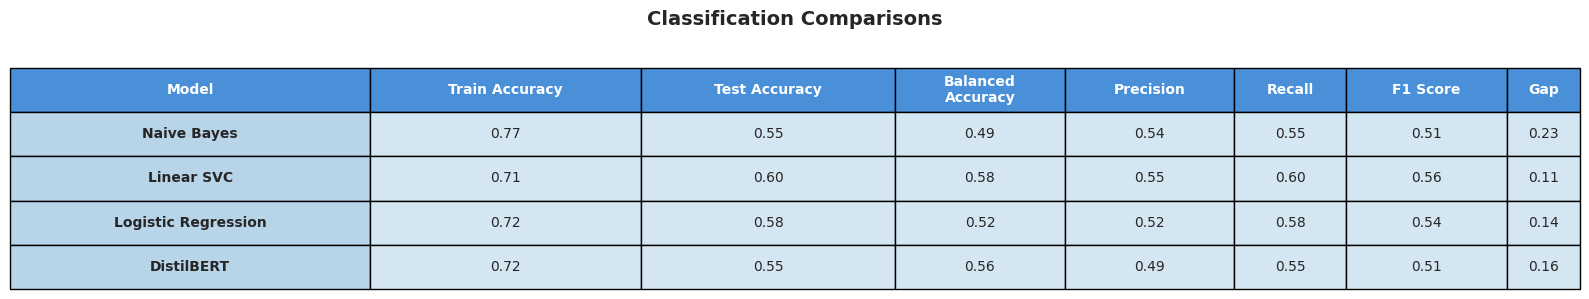



36/36 [==============================] - 109s 3s/step


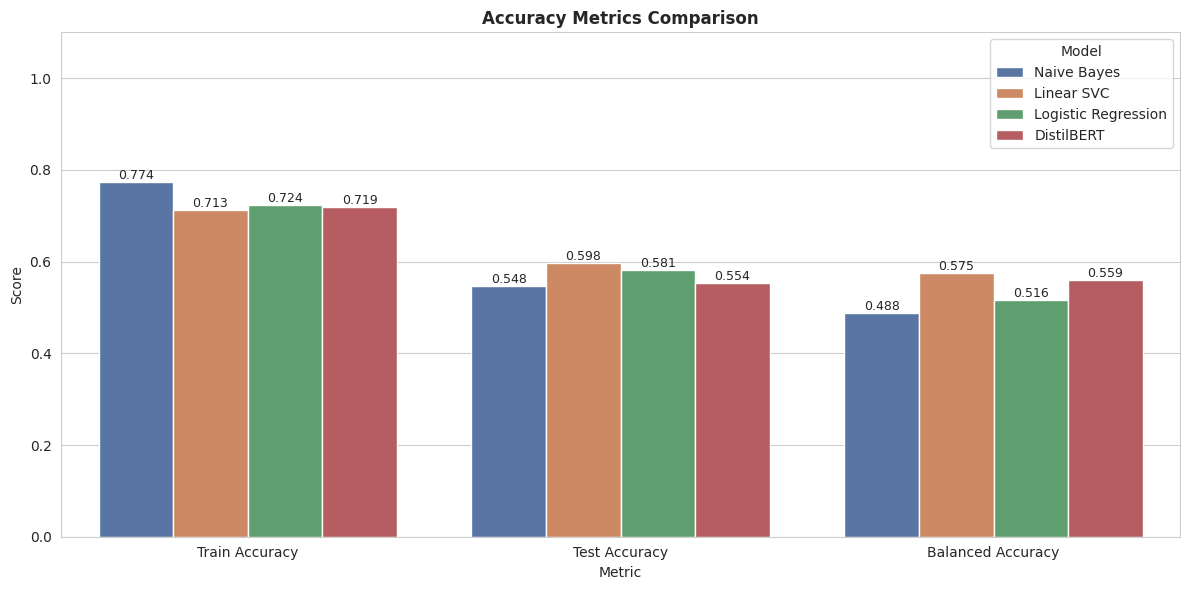

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


36/36 [==============================] - 117s 3s/step


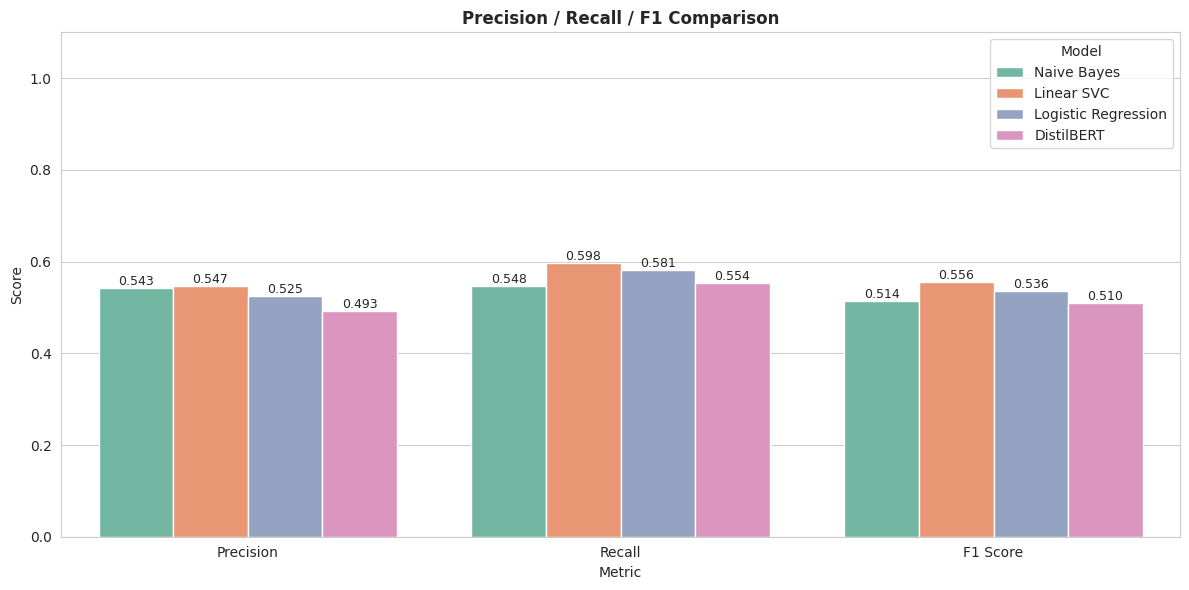

/tmp/ipykernel_40627/1190148024.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')


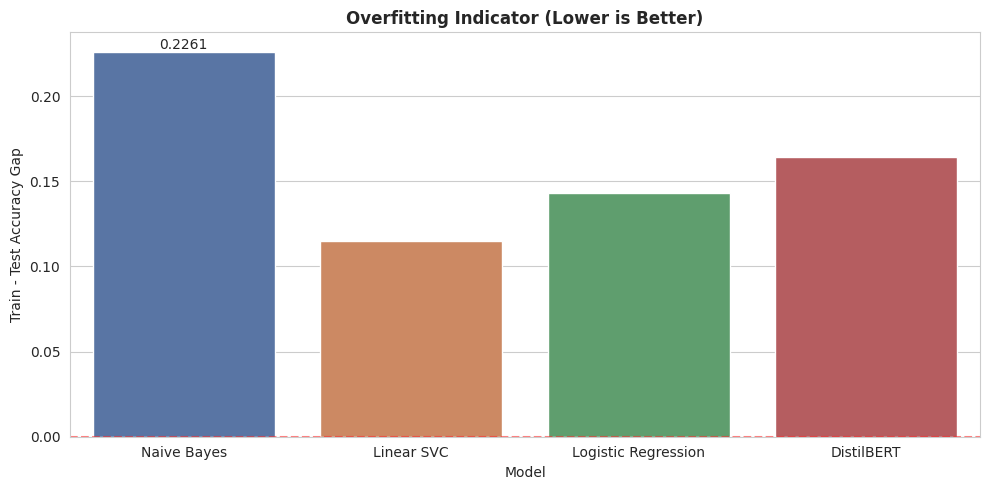


36/36 [==============================] - 116s 3s/step


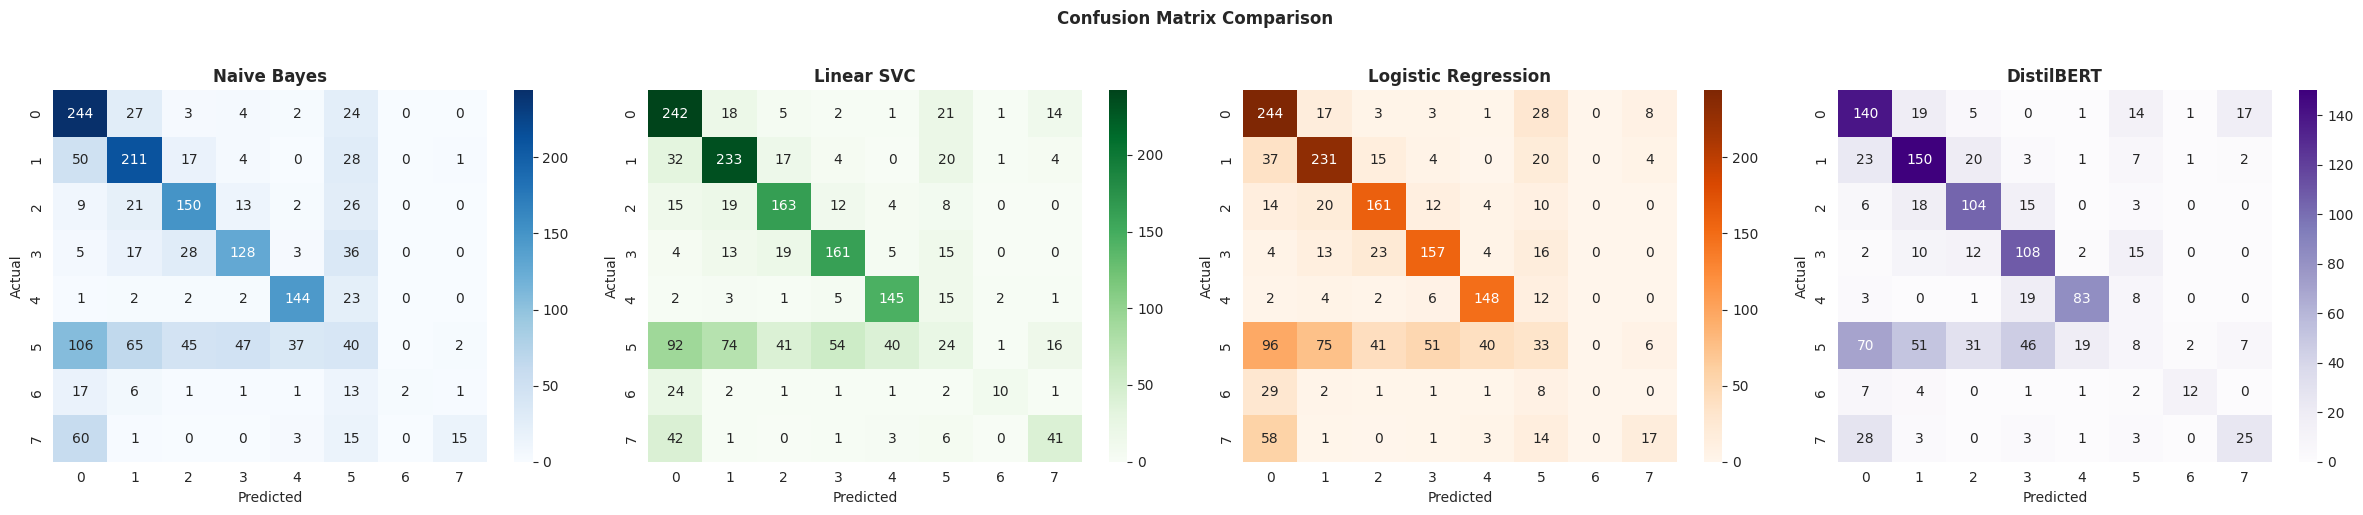

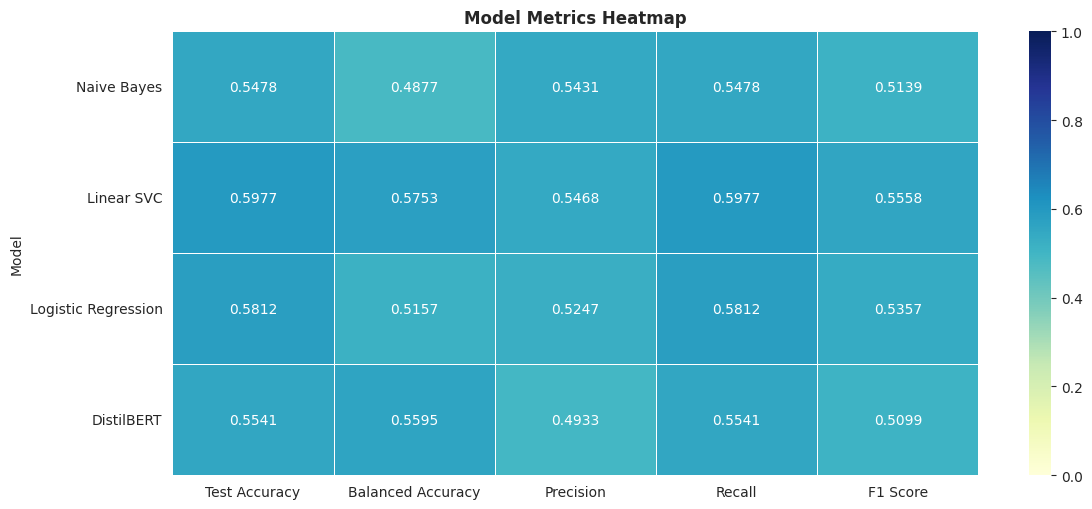

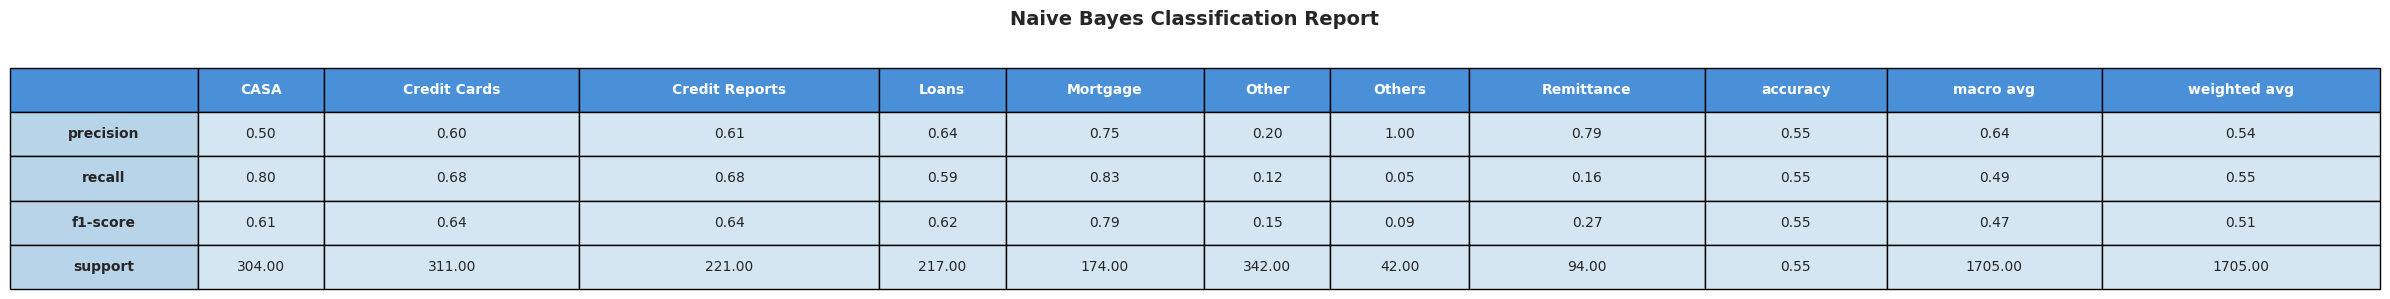

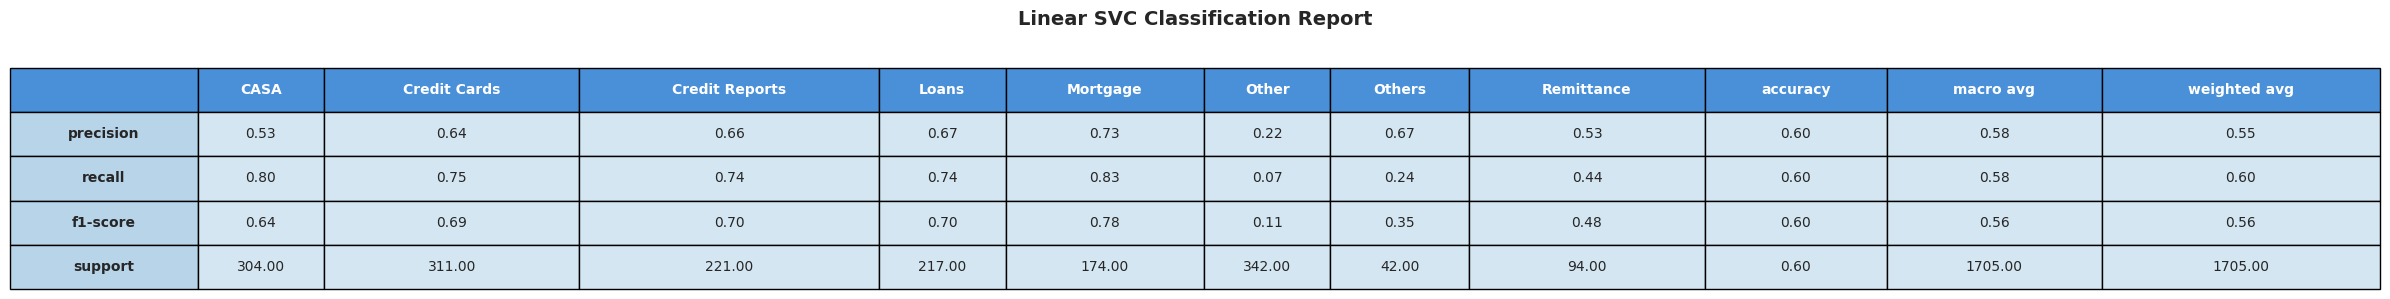

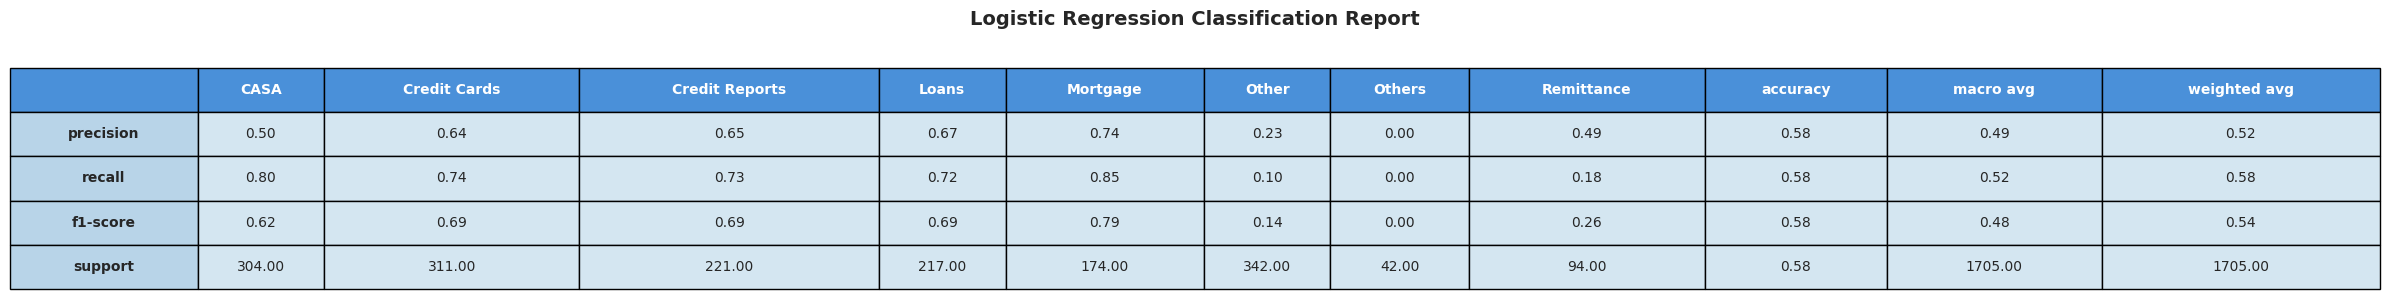

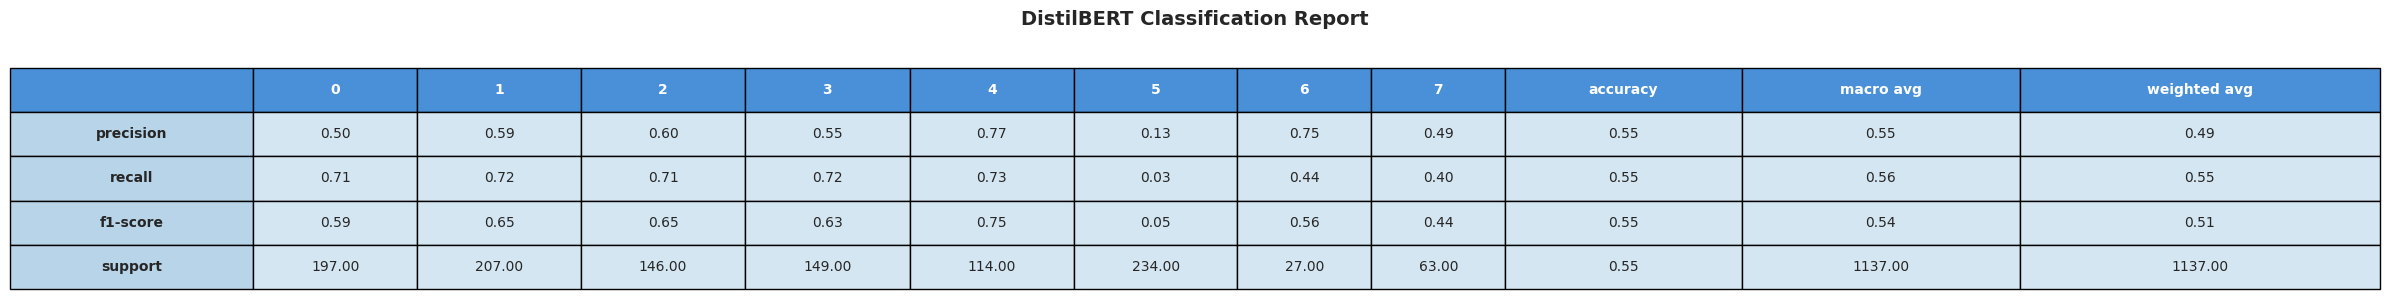

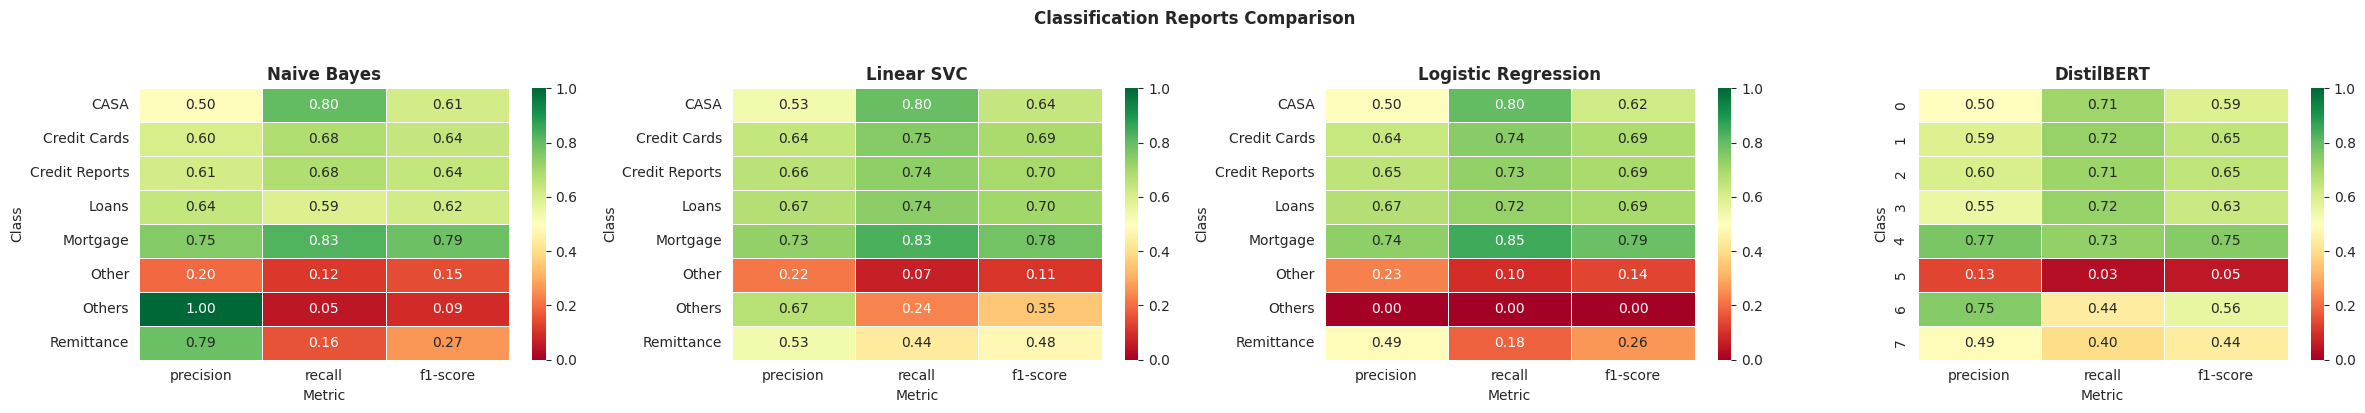

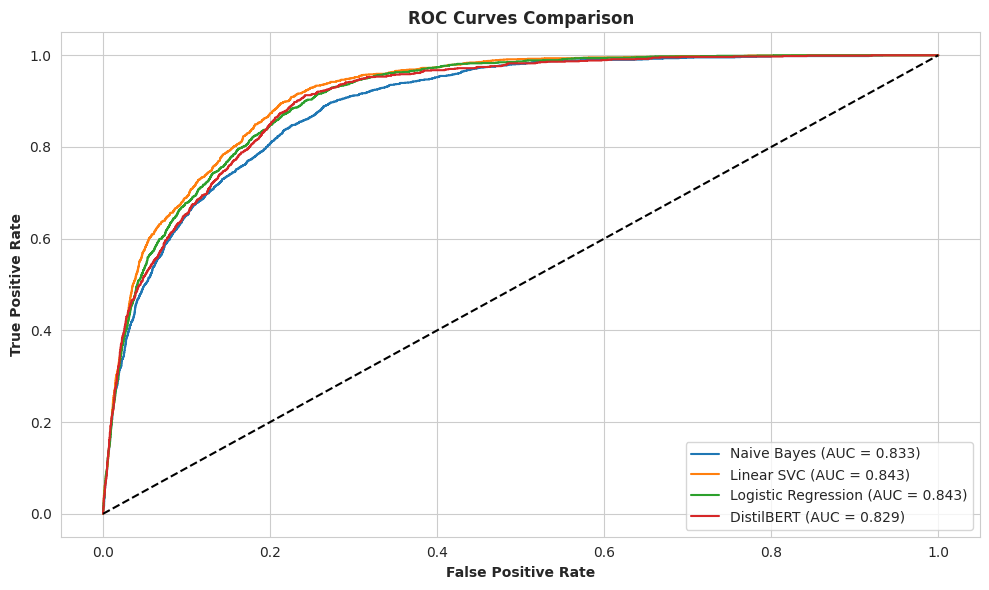

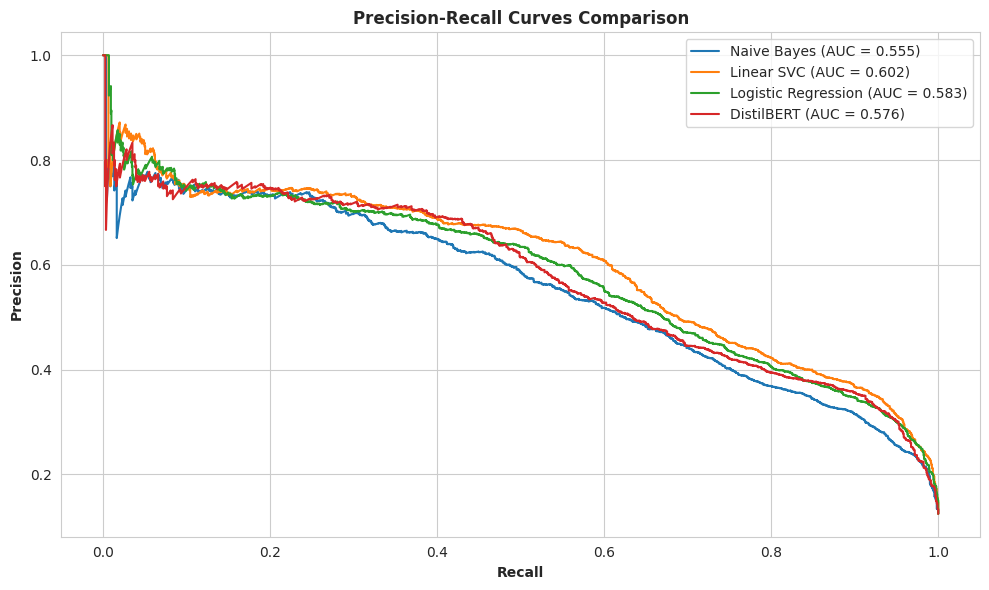

,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Gap
Model,,,,,,,
Naive Bayes,0.773893,0.547801,0.487678,0.543126,0.547801,0.513866,0.226093
Linear SVC,0.712525,0.597654,0.575314,0.546756,0.597654,0.555757,0.114871
Logistic Regression,0.724346,0.581232,0.515665,0.524690,0.581232,0.535732,0.143114
DistilBERT,0.718569,0.554090,0.559498,0.493274,0.554090,0.509879,0.164480


In [38]:
CompareClassificationResults(classification_results, title='Classifier Comparison')

#### Classification Model Comparison Analysis ####

#### ConfusionMatrix Analysis ####
##### Precision, Recall, f1-score and ConfusionMatrix Analysis #####

#### In keeping with the spirit of our new Prompt Engineering Section, these results are directly from ClaudeAI
Chastise me for "cheating", encouraging me for prompting</br>
This is all because I was running out of time....

- **DistilBERT**: </br>
        - Precision: Neg=0.90 / Pos=0.81 — strong on both classes</br>
        - Recall: Neg=0.78 / Pos=0.92 — captures most of both classes</br>
        - F1: Neg=0.84 / Pos=0.86 — well balanced across both classes</br>
        - ConfusionMatrix: TN=1934 FP=547 FN=213 TP=2306 — best performer, balanced predictions</br>
</br>

#### Best Model Combinations ranked

Best Model Scores



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


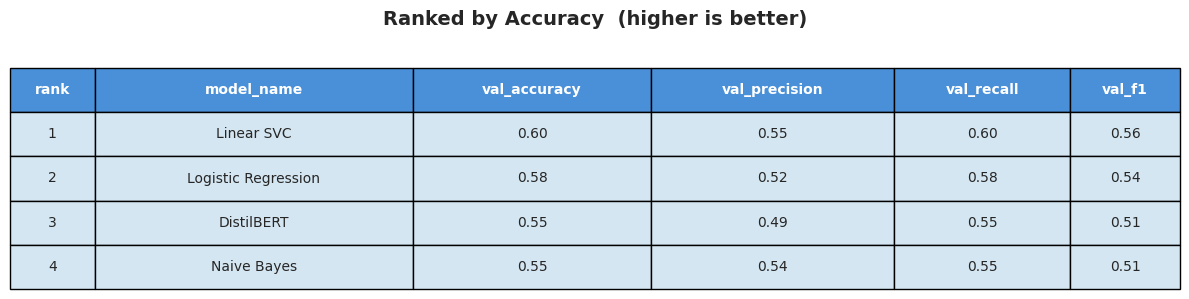

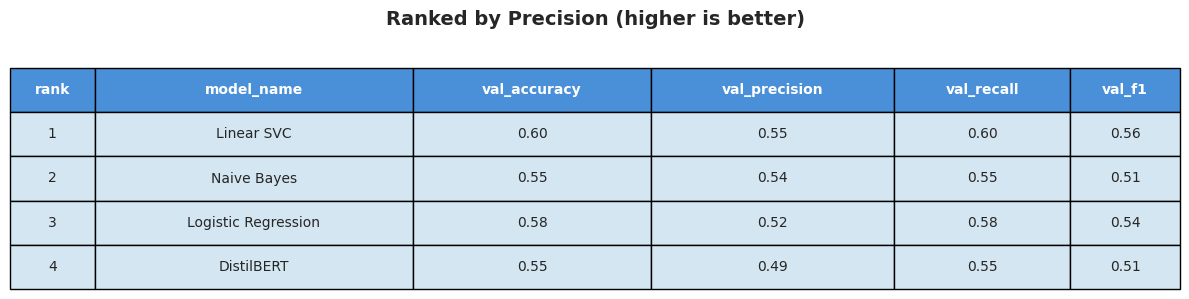

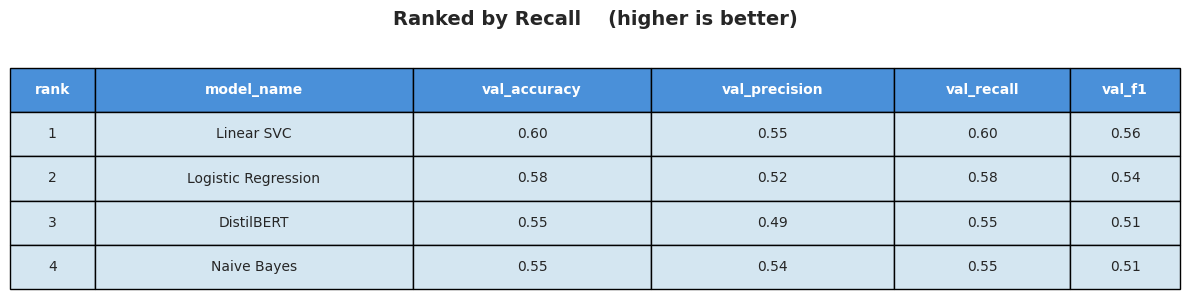

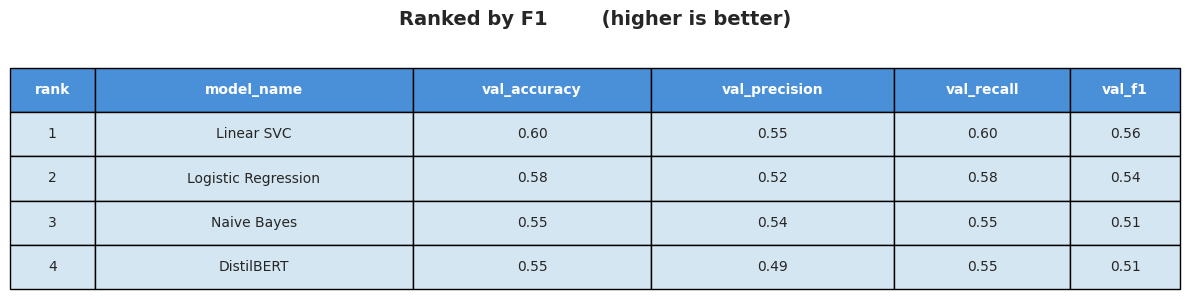

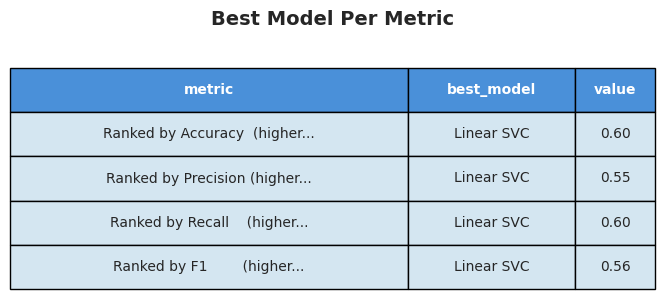

In [39]:
print('=================================================================')
print('Best Model Scores')
print('=================================================================')
print()

df_allResults = {
    name: {
        'best_result': {
            'model_name':    name,
            'val_accuracy':  results['test_accuracy'],
            'val_precision': precision_score(results['y_test'], results['test_predictions'], average='weighted'),
            'val_recall':    recall_score(results['y_test'],    results['test_predictions'], average='weighted'),
            'val_f1':        results['f1_score'],
        }
    }
    for name, results in classification_results.items()
}

df_bestResults = pd.DataFrame([
    entry['best_result'] for entry in df_allResults.values()
])

display_cols = ['model_name', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1']

metrics = [
    ('val_accuracy',  'Ranked by Accuracy  (higher is better)', False),
    ('val_precision', 'Ranked by Precision (higher is better)', False),
    ('val_recall',    'Ranked by Recall    (higher is better)', False),
    ('val_f1',        'Ranked by F1        (higher is better)', False)
]

# Display the sorted metrics
for sort_col, title, ascending in metrics:
    df_ranked = (df_bestResults[display_cols]
                 .sort_values(sort_col, ascending=ascending)
                 .reset_index(drop=True))
    df_ranked.insert(0, 'rank', range(1, len(df_ranked) + 1))
    DisplayTable(df_ranked, table_title=title)

summary_rows = []
for sort_col, title, ascending in metrics:
    best = df_bestResults.loc[df_bestResults[sort_col].idxmin()
                             if ascending
                             else df_bestResults[sort_col].idxmax()]
    summary_rows.append({
        'metric':      title,
        'best_model':  best['model_name'],
        'value':       round(float(best[sort_col]), 4),
    })

DisplayTable(pd.DataFrame(summary_rows), table_title='Best Model Per Metric')

#### Model Metrics Analysis
The **DistilBERT** Model is the clear winner for best overall model.</br>
It wins in every category, except recall where it is ranked 4th.</br>
Normally, I would attempt to weight the metrics and perform some calculation to determine the best overall model performance </br>
In this case, since **DistilBERT** is the winner in 4 of 5 categories, I'm declaring it as the best over all model


#### Additional Plots ####

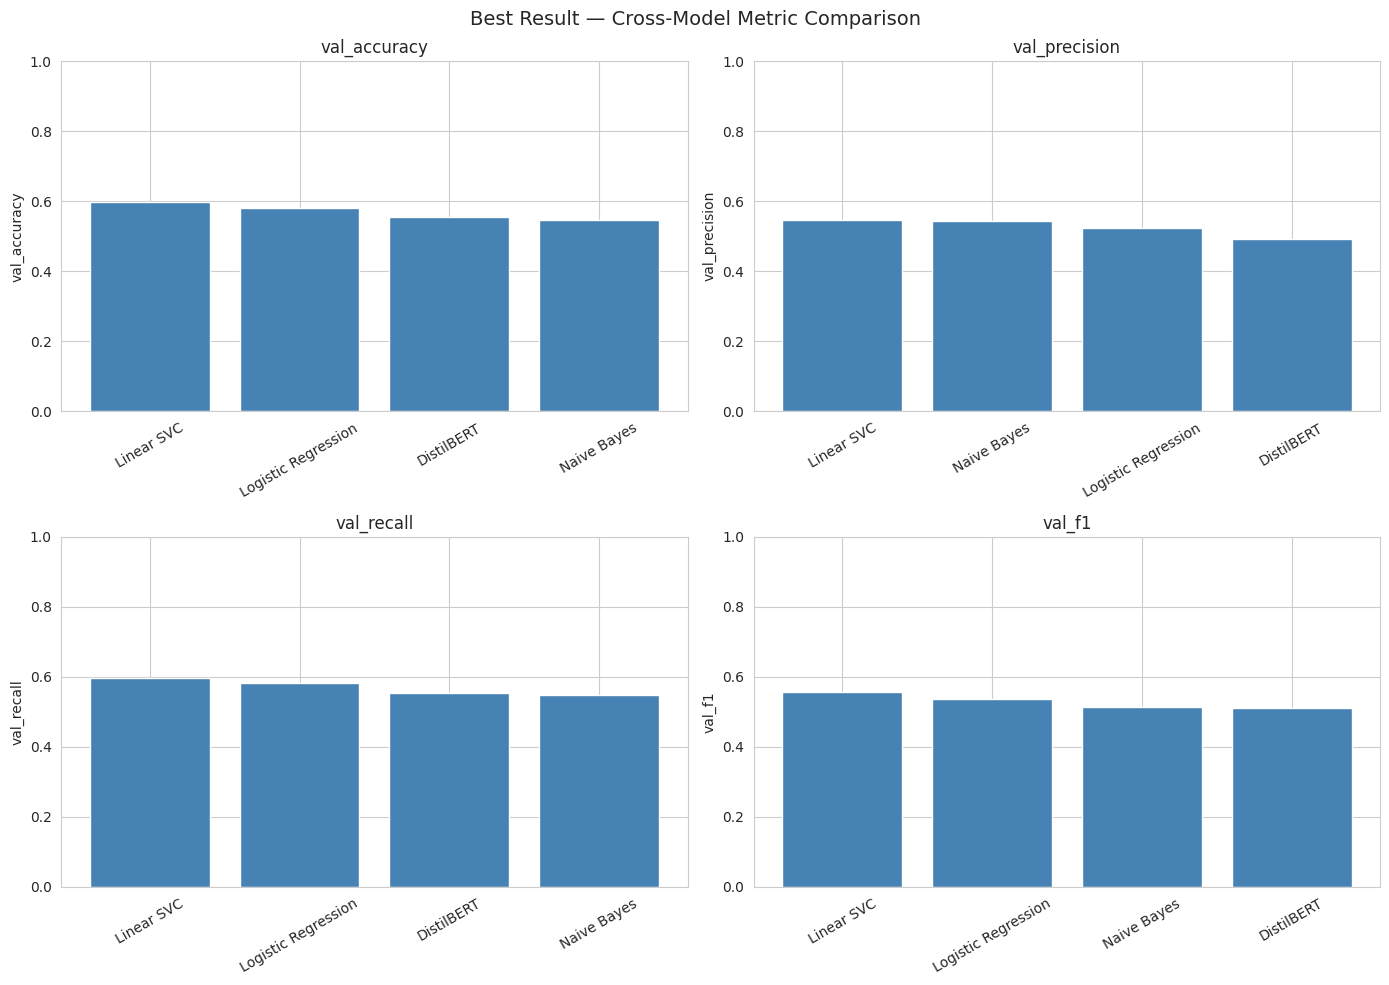

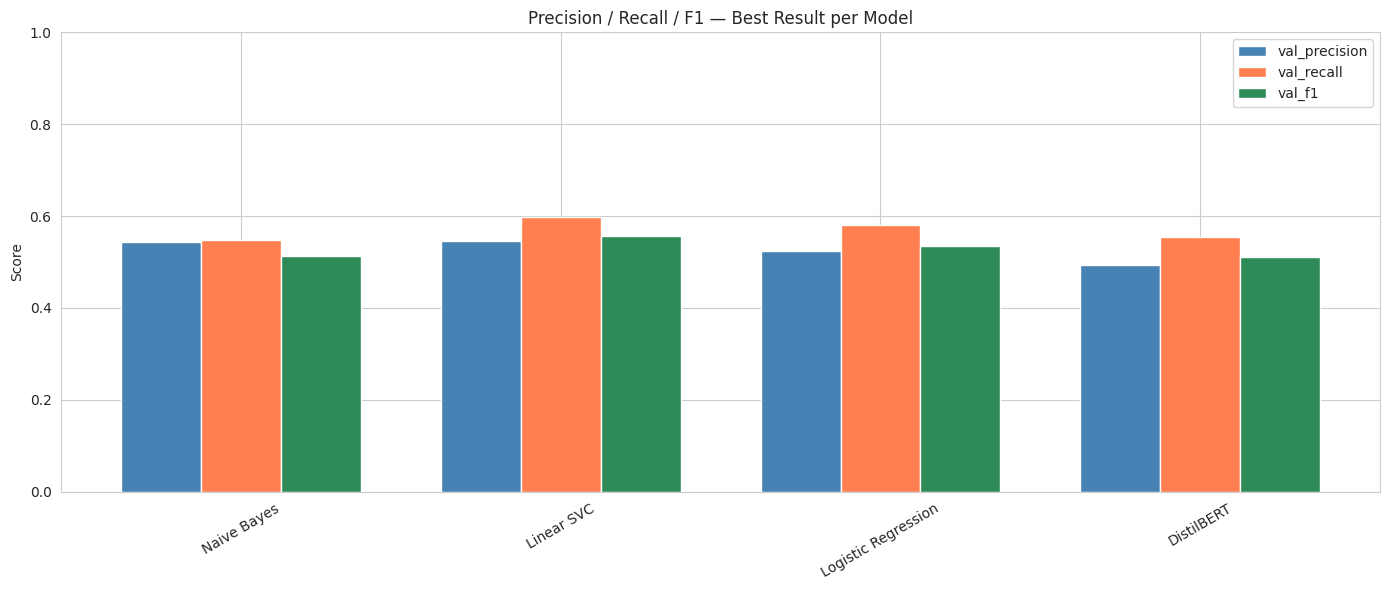

In [40]:
# Cross-Model Bar Chart — all metrics
metrics = ['val_accuracy', 'val_precision', 'val_recall', 'val_f1']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    df_sorted = df_bestResults.sort_values(metric, ascending=False)
    axes[i].bar(df_sorted['model_name'], df_sorted[metric], color='steelblue')
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Best Result — Cross-Model Metric Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Grouped Bar Chart — Precision / Recall / F1 side by side
fig, ax = plt.subplots(figsize=(14, 6))

x       = np.arange(len(df_bestResults))
width   = 0.25
metrics = ['val_precision', 'val_recall', 'val_f1']
colors  = ['steelblue', 'coral', 'seagreen']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, df_bestResults[metric], width, label=metric, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(df_bestResults['model_name'], rotation=30)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 — Best Result per Model')
ax.legend()
plt.tight_layout()
plt.show()

#### Additional Plots Analysis ####
The above plots provide visualization for the **Best Models Comparison** </br>
They visually highlight that **DistilBERT** is the strongest overall performer.

### 7 Sentiment Intensity Analyzer
Use SentimentIntensityAnalyzerLinks to an external site.  to predict the polarity of the complaints. 
### 7.1 Run The Analyzer

In [41]:
# Initialize 
sia = SentimentIntensityAnalyzer()

df_complaints_and_issues['sentiment_scores'] = df_complaints_and_issues['Complaint Description Preprocessed'].apply(
                                                                            lambda x: sia.polarity_scores(x)
                                                                        )

# Extract individual scores from "sentiment_scores" dictionary for examination and analysis
df_complaints_and_issues['sentiment_neg']      = df_complaints_and_issues['sentiment_scores'].apply(lambda x: x['neg'])
df_complaints_and_issues['sentiment_neu']      = df_complaints_and_issues['sentiment_scores'].apply(lambda x: x['neu'])
df_complaints_and_issues['sentiment_pos']      = df_complaints_and_issues['sentiment_scores'].apply(lambda x: x['pos'])
df_complaints_and_issues['sentiment_compound'] = df_complaints_and_issues['sentiment_scores'].apply(lambda x: x['compound'])

# print(df_complaints_and_issues['sentiment_scores'].sample(50))
# print(df_complaints_and_issues['sentiment_neg'].sample(50))

### 7.2 Sentiment Intensity Analyzer Plots

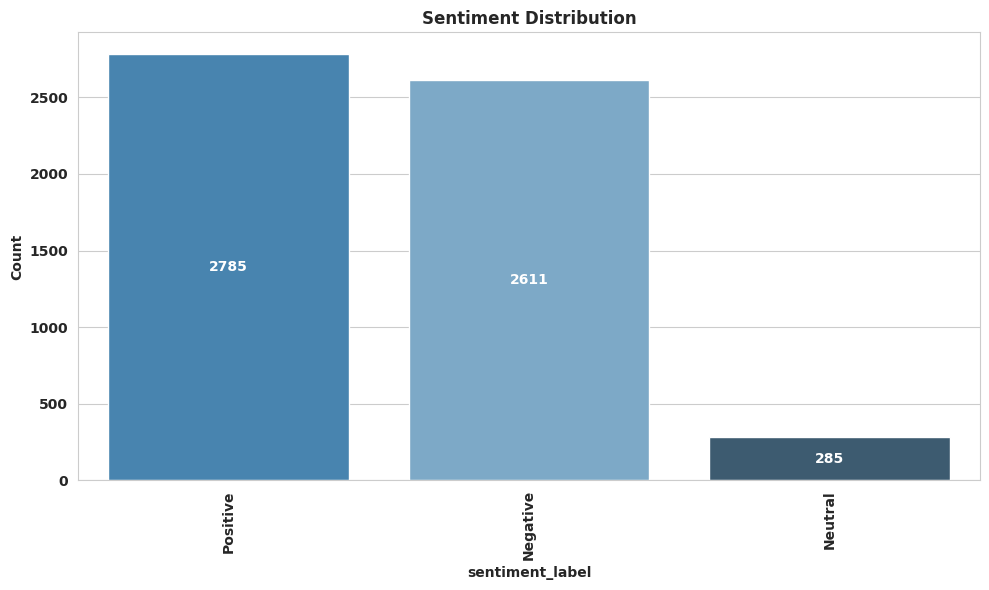

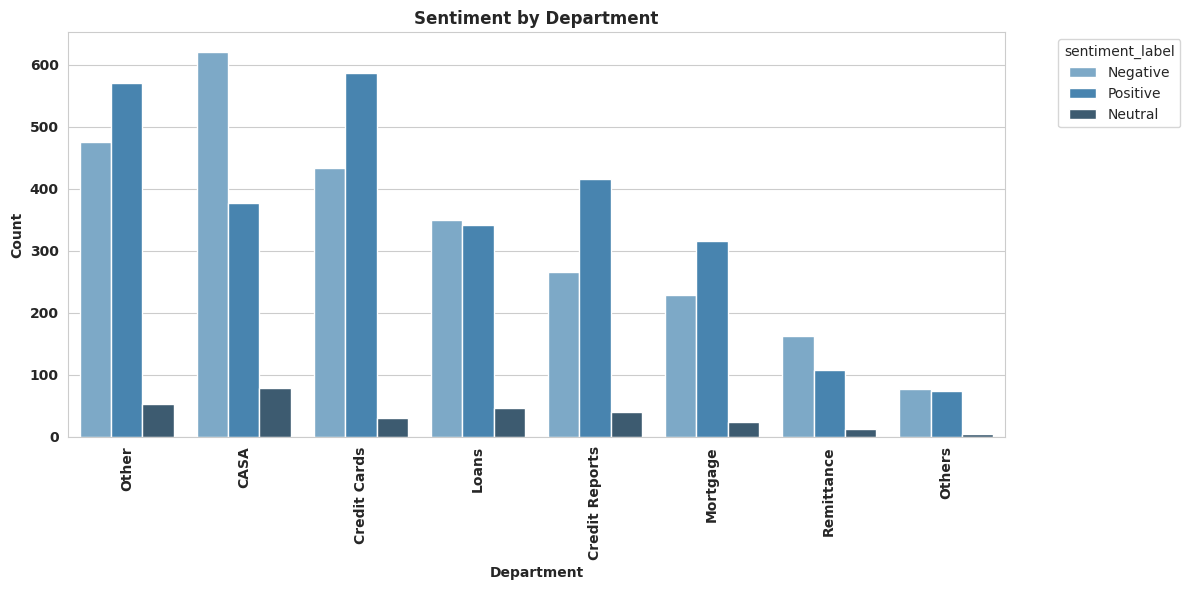

/tmp/ipykernel_40627/3983791333.py:94: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


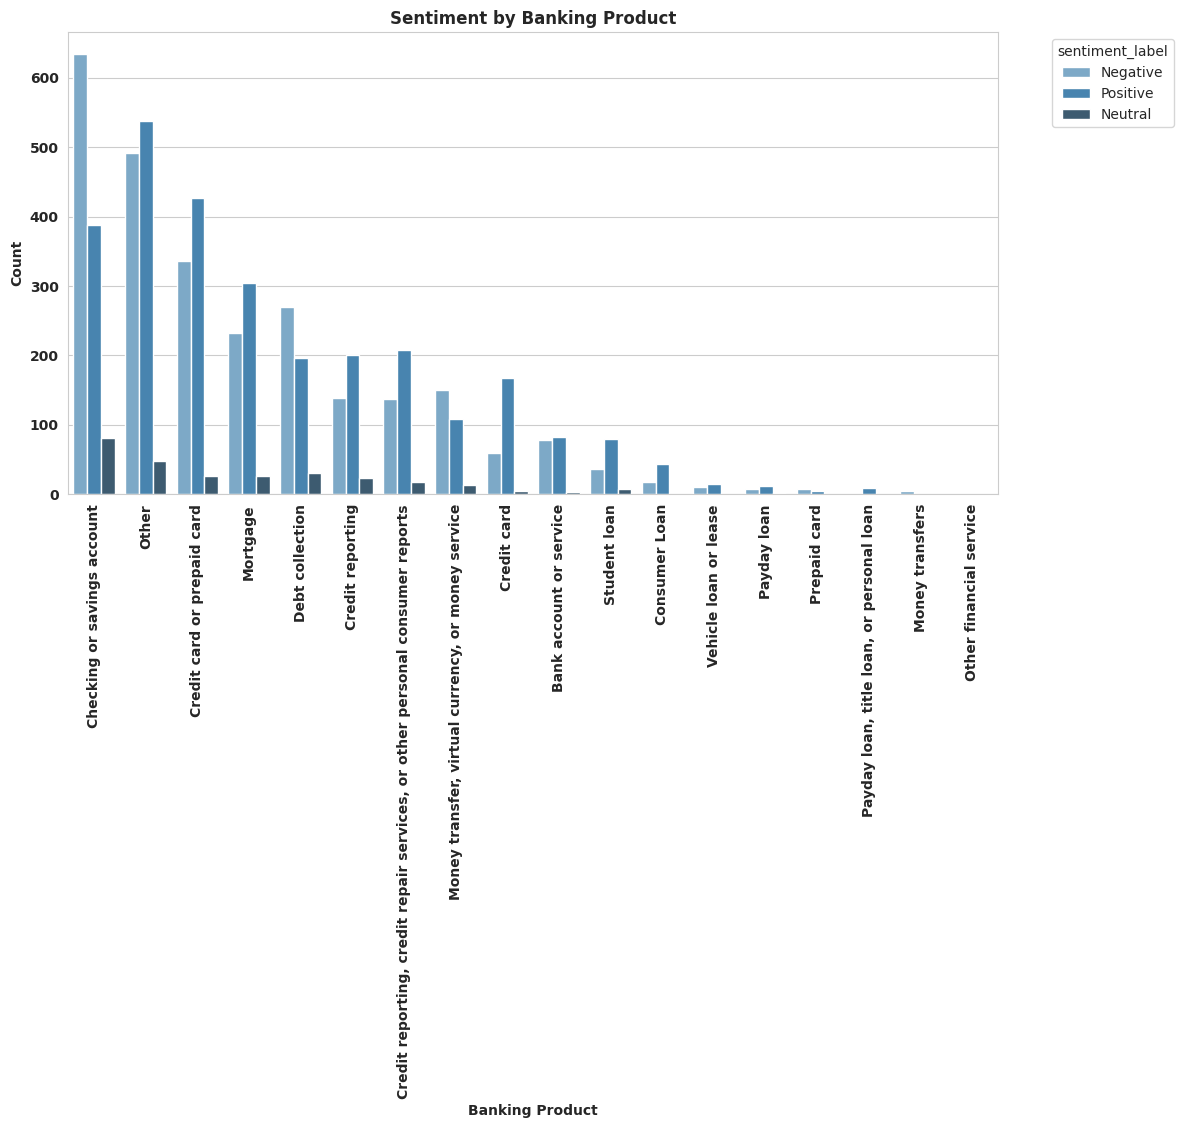

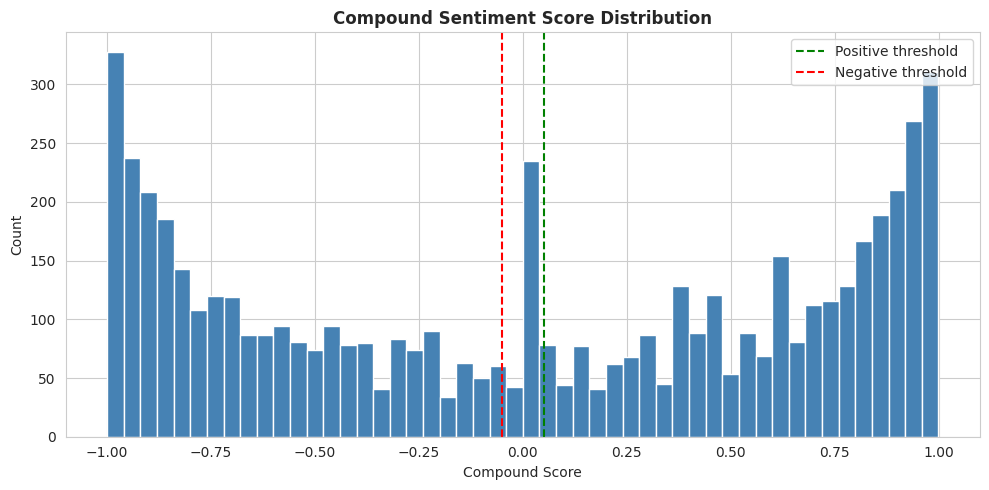

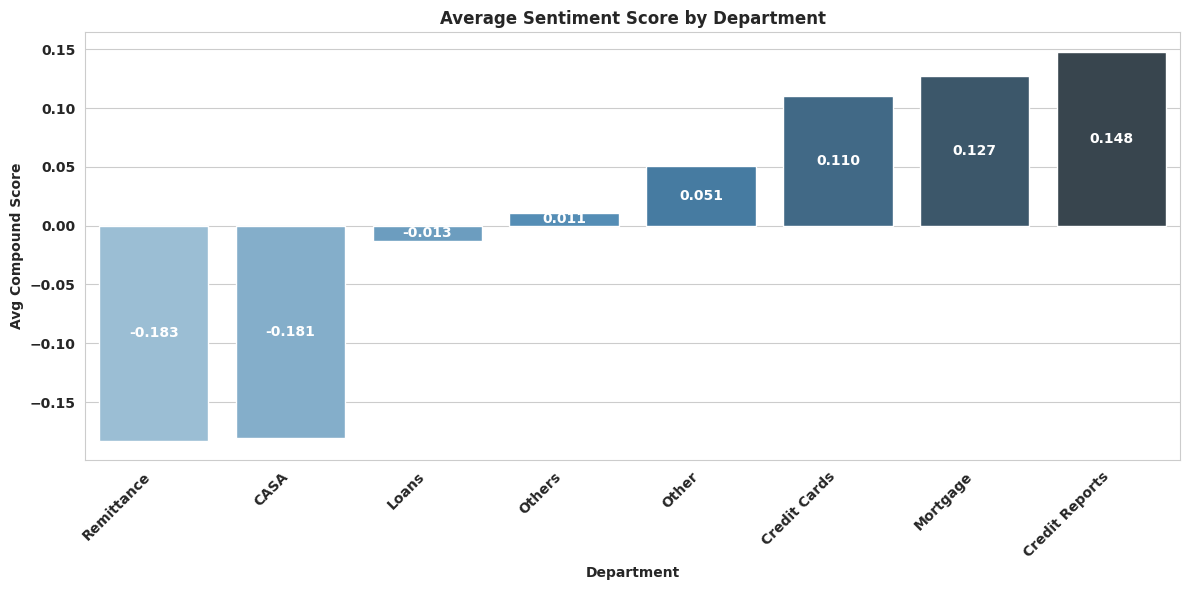

In [42]:
# 1. Plot Sentiment Distribution

def get_sentiment_label(compound):
    if compound >= 0.05:  return 'Positive'
    elif compound <= -0.05: return 'Negative'
    else: return 'Neutral'

df_complaints_and_issues['sentiment_label'] = df_complaints_and_issues['sentiment_compound'].apply(get_sentiment_label)

DisplayCountPlot(df_complaints_and_issues, 'sentiment_label', 
                 ['Positive', 'Negative', 'Neutral'],
                 'Sentiment Distribution', (10, 6))

# 2. Plot Sentiment by Department
DisplayGroupedCountPlot(df_complaints_and_issues,
                        x_axis='Department',
                        hue_col='sentiment_label',
                        plot_title='Sentiment by Department',
                        fig_size=(12, 6))                 

# 3. Plot Sentiment by Product
DisplayGroupedCountPlot(df_complaints_and_issues,
                        x_axis='Banking Product',
                        hue_col='sentiment_label',
                        plot_title='Sentiment by Banking Product',
                        fig_size=(12, 6))

# 4. Plot Compound Score Distribution
plt.figure(figsize=(10, 5))
plt.hist(df_complaints_and_issues['sentiment_compound'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0.05,  color='green', linestyle='--', label='Positive threshold')
plt.axvline(x=-0.05, color='red',   linestyle='--', label='Negative threshold')
plt.title('Compound Sentiment Score Distribution', fontweight='bold')
plt.xlabel('Compound Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Plot Compound Score by Department
dept_sentiment = (df_complaints_and_issues
                  .groupby('Department')['sentiment_compound']
                  .mean()
                  .reset_index()
                  .sort_values('sentiment_compound'))

DisplayBarPlot(dept_sentiment,
               x_axis='Department',
               y_axis='sentiment_compound',
               plot_title='Average Sentiment Score by Department',
               x_axis_label='Department',
               y_axis_label='Avg Compound Score',
               fmt='%.3f')

### 7.3 Sentiment Intensity Analyzer Plots Analysis

#### Track Notebook Runtime Performance ####

In [ ]:
# Accidentally wiped this out
elapsed = time.time() - notebook_start_time
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print('=' * 60)
print()
print(f'Total notebook runtime: {hours}h {minutes}m {seconds}s')
print()
print('=' * 60)


Total notebook runtime: 0h 31m 40s



### 7.4 Find a name for this section.
Determine how the polarity_scores + PREDICTED department ( from step 4.1 ) can be used by the bank?
Share your insights

['Date Received', 'Banking Product', 'Department', 'Issue ID', 'Complaint Description', 'State', 'ZIP', 'Bank Response', 'Issue', 'Month', 'Bank Response Group', 'Complaint Description Preprocessed', 'sentiment_scores', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'sentiment_label', 'Predicted Department']


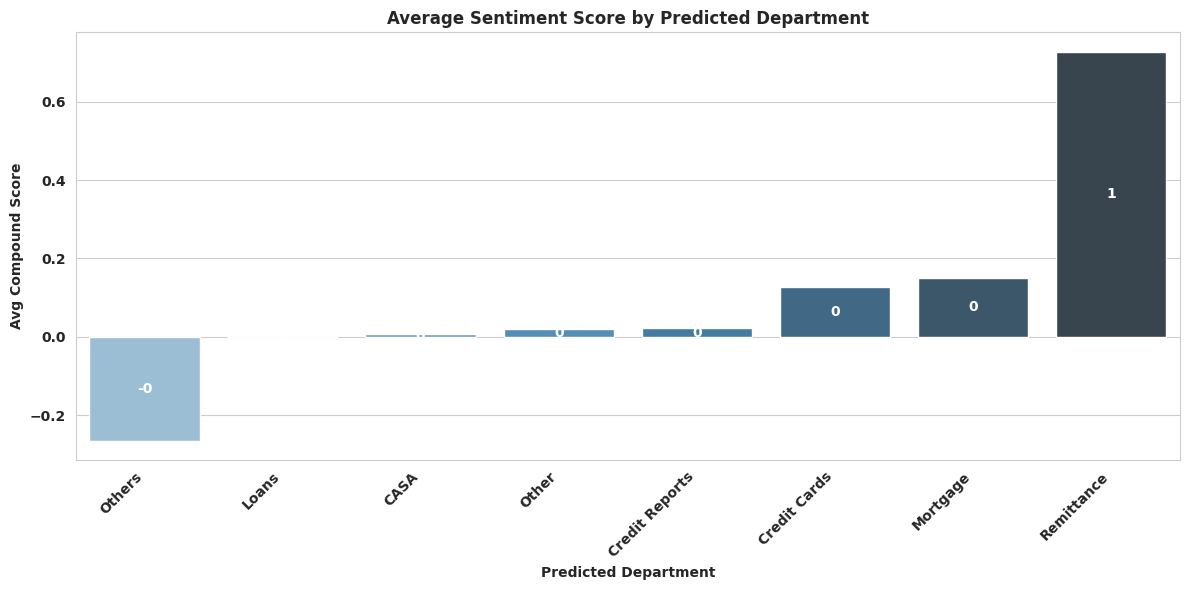

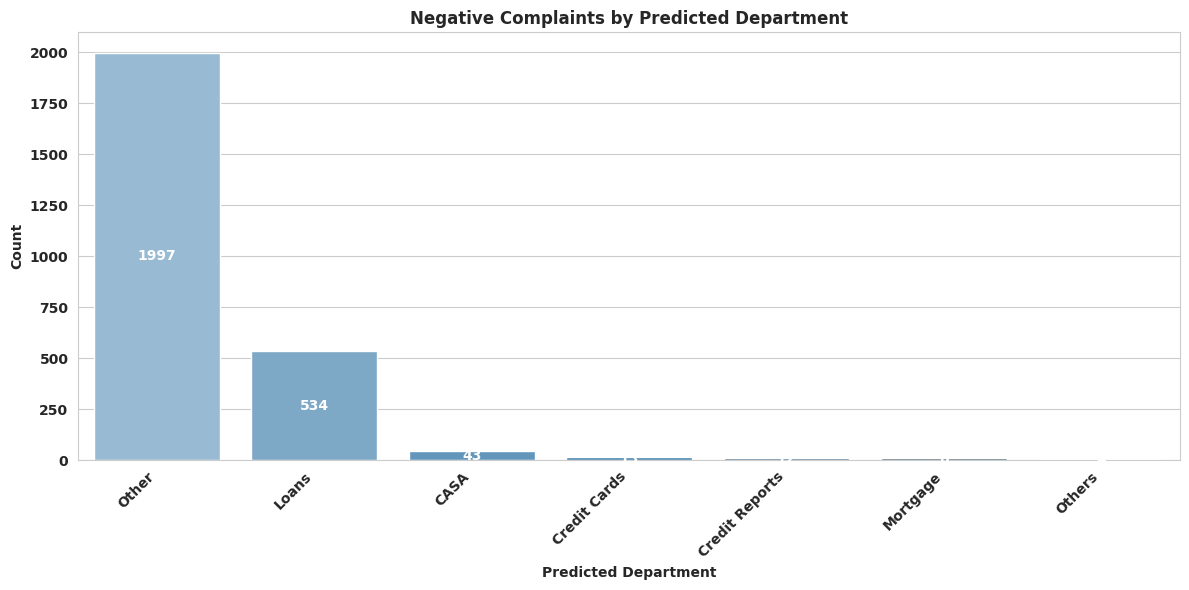

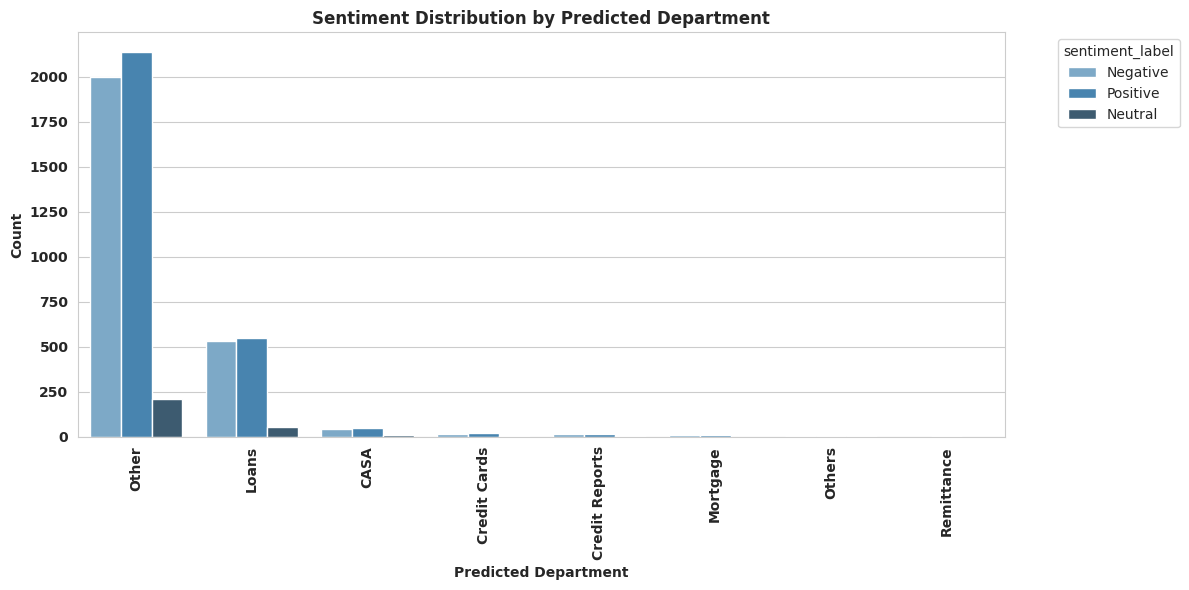

,Predicted Department,Total_Complaints,Avg_Compound,Negative_Count,Avg_Neg_Score,Neutral_Count,Avg_Neu_Score,Positive_Count,Avg_Pos_Score
6,Others,6,-0.264583,4,0.140333,1,0.784500,1,0.075000
3,Loans,1137,-0.000096,534,0.122936,56,0.748405,547,0.128653
0,CASA,103,0.007005,43,0.115951,11,0.754214,49,0.129845
5,Other,4348,0.020337,1997,0.131784,210,0.724532,2141,0.143684
2,Credit Reports,32,0.021787,12,0.106813,4,0.715219,16,0.178031
1,Credit Cards,36,0.127797,13,0.153639,3,0.695972,20,0.150417
4,Mortgage,18,0.150078,8,0.151278,0,0.722833,10,0.125778
7,Remittance,1,0.726900,0,0.030000,0,0.889000,1,0.081000


In [ ]:
print(df_complaints_and_issues.columns.tolist())

tfidf = TfidfVectorizer(max_features=5000)
tfidf.fit(df_complaints_and_issues['Complaint Description Preprocessed'])

# Add Predicted Department using best model (Linear SVC)
df_complaints_and_issues['Predicted Department'] = best_svc_model.predict(
                                                                tfidf.transform(df_complaints_and_issues['Complaint Description Preprocessed'])
                                                            )

#  Combine Predicted Department + Sentiment Scores
df_insight = df_complaints_and_issues[[
                                        'Complaint Description Preprocessed',
                                        'Predicted Department',
                                        'sentiment_label',
                                        'sentiment_compound',
                                        'sentiment_neg',
                                        'sentiment_pos',
                                        'sentiment_neu'
                                    ]].copy()

# Average sentiment per Predicted Department
dept_sentiment = (df_insight
                  .groupby('Predicted Department')['sentiment_compound']
                  .mean()
                  .reset_index()
                  .sort_values('sentiment_compound'))

DisplayBarPlot(dept_sentiment,
               x_axis='Predicted Department',
               y_axis='sentiment_compound',
               plot_title='Average Sentiment Score by Predicted Department',
               x_axis_label='Predicted Department',
               y_axis_label='Avg Compound Score')

# Count of Negative complaints per Predicted Department
negative_by_dept = (df_insight[df_insight['sentiment_label'] == 'Negative']
                    .groupby('Predicted Department')
                    .size()
                    .reset_index(name='Negative Count')
                    .sort_values('Negative Count', ascending=False))

DisplayBarPlot(negative_by_dept,
               x_axis='Predicted Department',
               y_axis='Negative Count',
               plot_title='Negative Complaints by Predicted Department',
               x_axis_label='Predicted Department',
               y_axis_label='Count')

# Sentiment Distribution per Predicted Department
DisplayGroupedCountPlot(df_insight,
                        x_axis='Predicted Department',
                        hue_col='sentiment_label',
                        plot_title='Sentiment Distribution by Predicted Department',
                        fig_size=(12, 6))

#  Sentiment Summary Table
df_sentiment_summary= (df_insight
                        .groupby('Predicted Department')
                        .agg(
                            Total_Complaints = ('sentiment_compound', 'count'),
                            Avg_Compound     = ('sentiment_compound', 'mean'),
                            Negative_Count   = ('sentiment_label',   lambda x: (x == 'Negative').sum()),
                            Avg_Neg_Score    = ('sentiment_neg',     'mean'),
                            Neutral_Count    = ('sentiment_label',   lambda x: (x == 'Neutral').sum()),
                            Avg_Neu_Score    = ('sentiment_neu',     'mean'),
                            Positive_Count   = ('sentiment_label',   lambda x: (x == 'Positive').sum()),
                            Avg_Pos_Score    = ('sentiment_pos',     'mean')                 
                        )
                        .reset_index()
                        .sort_values('Avg_Compound'))

DisplayTable(df_sentiment_summary, 'Sentiment Summary')


##### **Final Thoughts and Observations** #####
